# 05 — Compute BOP Descriptors

Computes Bond Order Potential (BOP) moment descriptors for all training structures using the BOPfox software.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/Fe-Mo-POSCAR-initial-rescaled-AtomsObjects.pkl`
- **BOPfox binary** (not publicly distributed; contact authors for access)
- `bopfoxfeaturizer` Python package (private; available on request)

## Outputs
- `Fe-Mo/Descriptors/CNAV_parallel_Fe-Mo_*.csv` — pre-computed BOP descriptors (included in repo)

## Notes
> ⚠️ This notebook requires the BOPfox software, which is not publicly distributed.

> Pre-computed BOP descriptors for the training set are already provided in `Fe-Mo/Descriptors/` and do not need to be regenerated to run notebooks 07–08.



#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

In [65]:
from Tools.DatasetTools.Commoms import *
os.environ['PATH']+=':'+os.path.join(os.getcwd(),'dependencies/bopfox/src/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
from Tools.DatasetTools import GetBopFeatures as BOPG

## options:

In [68]:
dataset = 'Fe-Mo' #  'Cr-Co-W'# 'Fe-Mo'
elements = dataset.split('-')
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
globalmoments = 16
model_definitions = BOPG.model_definitions
cutoff = 'table'
atoms = ['initial', 'relaxed']
retry = False

In [69]:
from IPython.display import JSON
import json

In [70]:
 JSON(json.dumps(BOPG.model_definitions, indent=4, sort_keys=True) )

<IPython.core.display.JSON object>

In [71]:
target_case = 'EF_nmhcp' # only for correlation plots

In [72]:
BOPG.AtomsObjects.keys()

dict_keys(['initial', 'relaxed'])

In [73]:
AtomsObjects = {'initial' : load_atoms_objects(dataset,case='POSCAR.initial', scaling='rescaled'),
                'relaxed' : load_atoms_objects(dataset, case='POSCAR.relaxed-all', scaling='noscaled')
               }
BS = load_fully_curated_briefsummary(dataset)

In [74]:
try:
   from dependencies.bopdftprojections.bopdftprojections.projections import Projections, Canonicalmodel
   has_dftprojections = True
except ImportError:
   has_dftprojections = False
import shutil

In [75]:
if has_dftprojections:
   P = Projections()
   C = Canonicalmodel()

In [76]:
for (model, moments, case), result in BOPG.results.items():
    notoutliers = result.index.intersection(BS.index)
    BOPG.results[(model, moments, case)] = result.loc[notoutliers]
    print(result.shape)

(291, 11)
(291, 11)
(256, 11)
(256, 11)


In [77]:
BOPG.results.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

In [78]:
BOPG.results[('0.7projections_0.5os',globalmoments, 'initial')].columns

Index(['U_bind', 'U_bond_atom', 'U_bond_atom_list', 'moments',
       'normed_moments', 'an', 'bn', 'sigma', 'Ainf', 'Binf', 'modelsfile'],
      dtype='object')

In [79]:
BOPG.results[('0.7projections_0.5os', globalmoments, 'initial')].isna().sum(axis=0)#any()

U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
modelsfile          0
dtype: int64

In [80]:
example = BOPG.results[('0.7projections_0.5os', globalmoments, 'initial')].query('index.str.contains("sigma.FM")')

In [81]:
example

,U_bind,U_bond_atom,U_bond_atom_list,moments,normed_moments,an,bn,sigma,Ainf,Binf,modelsfile
Mo_sv30.sigma.FM,-292.578511,-292.696994,"[-10.5591178622, -9.0428466461, -9.042845985, ...","[[-1.6800000000000002, 9.61988, -46.3804, 252....","[[0.1049827583, 0.2112853453, 0.0269128187, 0....","[[-1.6800000000000002, -2.76562, -2.72784, -2....","[[0.0, 2.6072, 1.94623, 2.31075, 2.07374, 2.36...","[[1.0, 0.20967062789999996, -0.1542827054, -0....","[[-2.2916324946], [-2.2950689347], [-2.2950689...","[[2.9130140251], [2.7178031061], [2.7178031017...",tempmodels/Fe-Mo-FeMo_0.7projections_0.5os.bx


In [82]:
np.set_printoptions(precision=2,linewidth=125)

In [83]:
np.array(example['moments'][0])

array([[-1.68e+00,  9.62e+00, -4.64e+01,  2.53e+02, -1.41e+03,  8.10e+03, -4.77e+04,  2.86e+05, -1.74e+06,  1.07e+07,
        -6.65e+07,  4.18e+08, -2.64e+09,  1.68e+10, -1.08e+11,  6.93e+11, -4.48e+12,  2.91e+13, -1.90e+14,  1.24e+15],
       [-1.68e+00,  9.62e+00, -4.64e+01,  2.53e+02, -1.41e+03,  8.10e+03, -4.77e+04,  2.86e+05, -1.74e+06,  1.07e+07,
        -6.65e+07,  4.18e+08, -2.64e+09,  1.68e+10, -1.08e+11,  6.93e+11, -4.48e+12,  2.91e+13, -1.90e+14,  1.24e+15],
       [-1.68e+00,  8.24e+00, -3.83e+01,  1.98e+02, -1.06e+03,  5.87e+03, -3.35e+04,  1.95e+05, -1.16e+06,  6.97e+06,
        -4.24e+07,  2.61e+08, -1.62e+09,  1.01e+10, -6.33e+10,  3.99e+11, -2.53e+12,  1.61e+13, -1.03e+14,  6.56e+14],
       [-1.68e+00,  8.24e+00, -3.83e+01,  1.98e+02, -1.06e+03,  5.87e+03, -3.35e+04,  1.95e+05, -1.16e+06,  6.97e+06,
        -4.24e+07,  2.61e+08, -1.62e+09,  1.01e+10, -6.33e+10,  3.99e+11, -2.53e+12,  1.61e+13, -1.03e+14,  6.56e+14],
       [-1.68e+00,  8.24e+00, -3.83e+01,  1.98e+02, 

# Failed BOP Calculations 

In [84]:
for (model, moments, case), result in BOPG.results.items():
    print(f'{model} model, {moments} moemnts, {case} atoms:')
    print(result.isna().sum())
    print('-----------------')
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model, 16 moemnts, initial atoms:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
modelsfile          0
dtype: int64
-----------------
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf, modelsfile]
Index: []
canonical model, 16 moemnts, relaxed atoms:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
modelsfile          0
dtype: int64
-----------------
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf, modelsfile]
Index: []
0.7projections_0.5os model, 16 moemnts, initial atoms:
U_bind              0
U_bond_atom

##  remove bad data

In [85]:
BOPG.results.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

In [86]:
removenans = [result.dropna(inplace=True) for (model, moments, case), result in BOPG.results.items()]

In [87]:
for (model, moments, case), result in BOPG.results.items():
    print(f'{model} model, {case} atoms:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model, initial atoms:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
modelsfile          0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf, modelsfile]
Index: []
canonical model, relaxed atoms:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
modelsfile          0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf, modelsfile]
Index: []
0.7projections_0.5os model, initial atoms:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments   

# Arrangement and averaging BOP Features 

- expand arrays of atomwise quantities to quantities averages
- calculate shape factors, $b_1 / b_2$ averages (over CP and structure)
- remove features with constant values (null variance)

In [88]:
BOPG.resultscnav.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

In [89]:
examplemodel = ('0.7projections_0.5os', 16, 'initial')

In [90]:
BOPG.resultscnav[examplemodel].filter(regex='inf')

,Ainf_0_0,Ainf_0_CN12,Ainf_0_CN13,Ainf_0_CN14,Ainf_0_CN15,Ainf_0_CN16,Binf_0_0,Binf_0_CN12,Binf_0_CN13,Binf_0_CN14,Binf_0_CN15,Binf_0_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,-2.547265,-1.700949,0.0,0.000000,0.000000,-0.846315,3.233019,2.146699,0.0,0.000000,0.000000,1.086320
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-2.305675,-1.206855,0.0,-0.481782,-0.252624,-0.364415,2.467341,1.296715,0.0,0.528554,0.268038,0.374035
Fe_pv2Mo_sv11.mu-BBABB.FM,-2.360779,-1.265018,0.0,-0.347108,-0.401545,-0.347108,3.020709,1.626093,0.0,0.462860,0.468897,0.462860
Fe_pv8Mo_sv22.sigma-BBBAB.NM,-2.342987,-0.740052,0.0,-1.292508,-0.310427,0.000000,2.514930,0.831081,0.0,1.352168,0.331680,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,-2.454479,-1.319797,0.0,-0.411680,-0.361501,-0.361501,3.088864,1.671589,0.0,0.467017,0.475129,0.475129
...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,-2.490345,0.000000,0.0,-2.490345,0.000000,0.000000,3.160961,0.000000,0.0,3.160961,0.000000,0.000000
Mo_sv8.A15.NM,-2.221818,-0.555692,0.0,-1.666126,0.000000,0.000000,2.743953,0.688414,0.0,2.055539,0.000000,0.000000
Mo_sv1.fcc.NM,-2.361789,-2.361789,0.0,0.000000,0.000000,0.000000,3.029114,3.029114,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,-2.414319,-1.599926,0.0,0.000000,0.000000,-0.814393,3.114771,2.061450,0.0,0.000000,0.000000,1.053320


In [91]:
for (model, moments, case), features in BOPG.resultscnav.items():
    print(model, case, features.isnull().any().sum(), features.shape)

canonical initial 400 (292, 402)
canonical relaxed 400 (292, 402)
0.7projections_0.5os initial 508 (257, 510)
0.7projections_0.5os relaxed 508 (257, 510)


In [92]:
BOPG.resultscnav[('0.7projections_0.5os', 16, 'initial' )].query('index.str.contains("sigma.FM")').filter(regex='normed_moments_.*_0')

,normed_moments_0_0,normed_moments_1_0,normed_moments_2_0,normed_moments_3_0,normed_moments_4_0,normed_moments_5_0,normed_moments_6_0,normed_moments_7_0,normed_moments_8_0,normed_moments_9_0,normed_moments_10_0,normed_moments_11_0,normed_moments_12_0,normed_moments_13_0,normed_moments_14_0,normed_moments_15_0,normed_moments_16_0,normed_moments_17_0,normed_moments_18_0,normed_moments_19_0
Mo_sv30.sigma.FM,0.106949,0.209047,0.025669,0.067798,0.00487,0.026356,-0.000401,0.011501,-0.001372,0.005469,-0.001241,0.002784,-0.000916,0.001498,-0.00063,0.000843,-0.000421,0.000493,-0.000279,0.000298


# Compare relaxed to guess BOPS

In [93]:
inimodel = ('0.7projections_0.5os', 16, 'initial' )
rlxmodel = ('0.7projections_0.5os', 16, 'relaxed' )

In [94]:
BOPG.resultscnav[rlxmodel]

,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_0_0,moments_0_CN12,moments_0_CN13,moments_0_CN14,...,Binf_0_CN15,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom
Fe_pv4Mo_sv20.C36-ABBBB.FM,-15.333979,-13.577696,0.0,0.000000,0.000000,-1.756283,-2.001667,-1.120000,0.0,0.000000,...,0.000000,1.035948,1.022503,1.176396,0.0,0.000000,0.000000,0.692365,-180.145250,-185.382273
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-12.970582,-3.428241,0.0,-1.539024,-0.721597,-7.281719,-2.226226,-1.402076,0.0,-0.380377,...,0.263463,0.361033,1.024846,0.969486,0.0,1.135940,1.092094,0.986802,-322.704359,-345.825087
Fe_pv2Mo_sv11.mu-BBABB.FM,-15.773250,-5.018891,0.0,-8.567823,-1.009620,-1.176915,-1.976923,-0.904615,0.0,-0.258462,...,0.426916,0.422974,1.084399,1.272645,0.0,1.099463,0.383417,1.222888,-103.188345,-104.037145
Fe_pv8Mo_sv22.sigma-BBBAB.NM,-13.639302,-1.754980,0.0,-10.860049,-1.024273,0.000000,-2.194667,-1.074667,0.0,-0.896000,...,0.341743,0.000000,1.040565,0.726093,0.0,1.188558,1.202942,0.000000,-202.745565,-206.686310
Fe_pv2Mo_sv11.mu-BBBBA.NM,-15.859830,-5.031151,0.0,-1.079172,-1.102213,-8.647294,-1.976923,-0.904615,0.0,-0.555385,...,0.464500,0.464500,1.101268,1.233512,0.0,0.578098,1.030773,1.125754,-102.523096,-105.052152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,-9.637696,0.000000,0.0,-9.637696,0.000000,0.000000,-1.680000,0.000000,0.0,-1.680000,...,0.000000,0.000000,1.201199,0.000000,0.0,1.201199,0.000000,0.000000,-9.637696,-9.637696
Mo_sv8.A15.NM,-18.193457,-10.910591,0.0,-7.282865,0.000000,0.000000,-1.680000,-0.420000,0.0,-1.260000,...,0.000000,0.000000,1.293775,1.294717,0.0,1.293459,0.000000,0.000000,-77.529874,-77.537692
Mo_sv1.fcc.NM,-9.408296,-9.408296,0.0,0.000000,0.000000,0.000000,-1.680000,-1.680000,0.0,0.000000,...,0.000000,0.000000,1.156013,1.156013,0.0,0.000000,0.000000,0.000000,-9.408295,-9.408295
Mo_sv6.C15.NM,-17.473085,-13.936707,0.0,0.000000,0.000000,-3.536378,-1.680000,-1.120000,0.0,0.000000,...,0.000000,1.018632,1.210154,1.185066,0.0,0.000000,0.000000,1.258329,-57.008386,-57.723822


In [95]:
BOPG.resultscnav[inimodel]

,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_0_0,moments_0_CN12,moments_0_CN13,moments_0_CN14,...,Binf_0_CN15,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom
Fe_pv4Mo_sv20.C36-ABBBB.FM,-16.477133,-14.519455,0.0,0.000000,0.000000,-1.957678,-2.001667,-1.120000,0.0,0.000000,...,0.000000,1.086320,1.039316,1.177875,0.0,0.000000,0.000000,0.731479,-197.997462,-199.163371
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-12.861017,-3.401887,0.0,-1.518361,-0.685699,-7.255070,-2.226226,-1.402076,0.0,-0.380377,...,0.268038,0.374035,1.009751,0.946518,0.0,1.135645,1.059122,0.991045,-320.368376,-342.957751
Fe_pv2Mo_sv11.mu-BBABB.FM,-17.056631,-5.631410,0.0,-9.133067,-1.084204,-1.207949,-1.976923,-0.904615,0.0,-0.258462,...,0.468897,0.462860,1.067311,1.290870,0.0,0.991340,0.291763,1.259482,-111.484128,-112.083516
Fe_pv8Mo_sv22.sigma-BBBAB.NM,-13.115813,-1.713123,0.0,-10.399461,-1.003229,0.000000,-2.194667,-1.074667,0.0,-0.896000,...,0.331680,0.000000,1.037164,0.721486,0.0,1.178984,1.230933,0.000000,-192.326064,-198.732306
Fe_pv2Mo_sv11.mu-BBBBA.NM,-16.240253,-5.187049,0.0,-1.105434,-1.068767,-8.879004,-1.976923,-0.904615,0.0,-0.555385,...,0.475129,0.475129,1.050129,1.245641,0.0,0.383542,0.933837,1.166116,-103.554628,-107.000478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,-9.585280,0.000000,0.0,-9.585280,0.000000,0.000000,-1.680000,0.000000,0.0,-1.680000,...,0.000000,0.000000,1.201493,0.000000,0.0,1.201493,0.000000,0.000000,-9.585281,-9.585281
Mo_sv8.A15.NM,-18.422201,-11.047802,0.0,-7.374399,0.000000,0.000000,-1.680000,-0.420000,0.0,-1.260000,...,0.000000,0.000000,1.293664,1.294676,0.0,1.293325,0.000000,0.000000,-78.505391,-78.513102
Mo_sv1.fcc.NM,-9.521157,-9.521157,0.0,0.000000,0.000000,0.000000,-1.680000,-1.680000,0.0,0.000000,...,0.000000,0.000000,1.156032,1.156032,0.0,0.000000,0.000000,0.000000,-9.521158,-9.521158
Mo_sv6.C15.NM,-18.143084,-14.477206,0.0,0.000000,0.000000,-3.665878,-1.680000,-1.120000,0.0,0.000000,...,0.000000,1.053320,1.211415,1.186542,0.0,0.000000,0.000000,1.259219,-59.236423,-59.928069


In [96]:
Moments_RLX = BOPG.resultscnav[rlxmodel].filter(regex='normed_moments')
Moments_INI = BOPG.resultscnav[inimodel].filter(regex='normed_moments')

In [97]:
from sklearn.metrics import r2_score

In [98]:
momentstr=r'$\tilde{{\mu}} $'

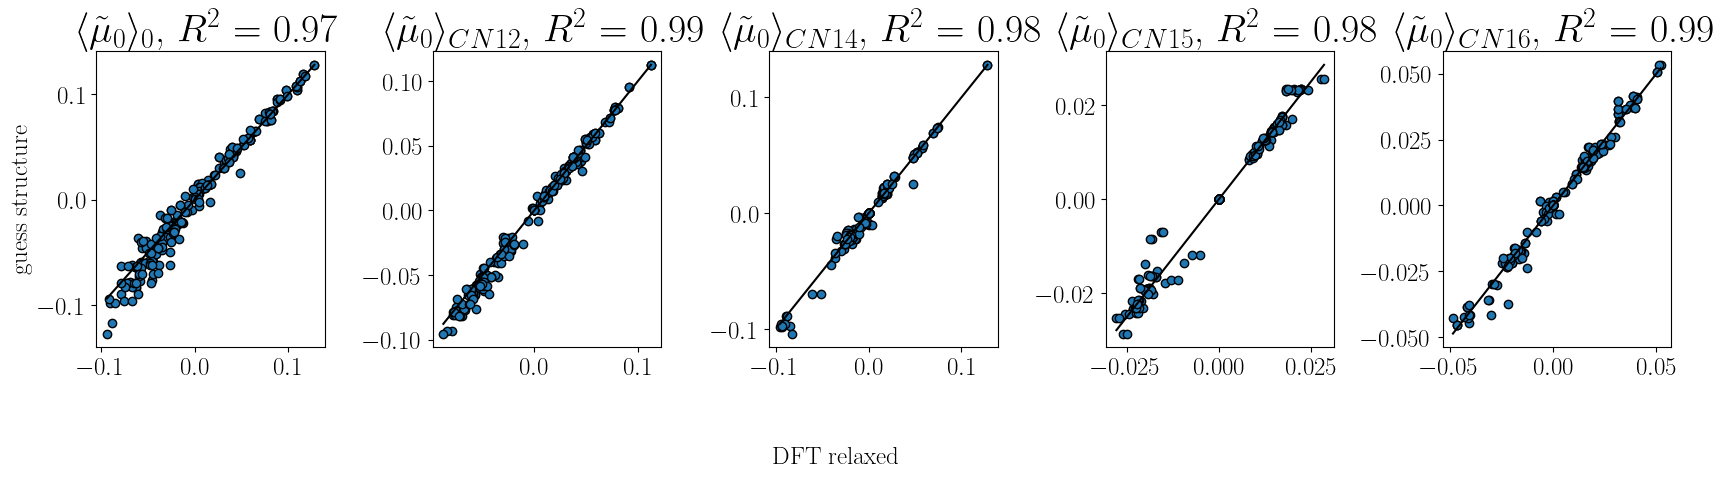

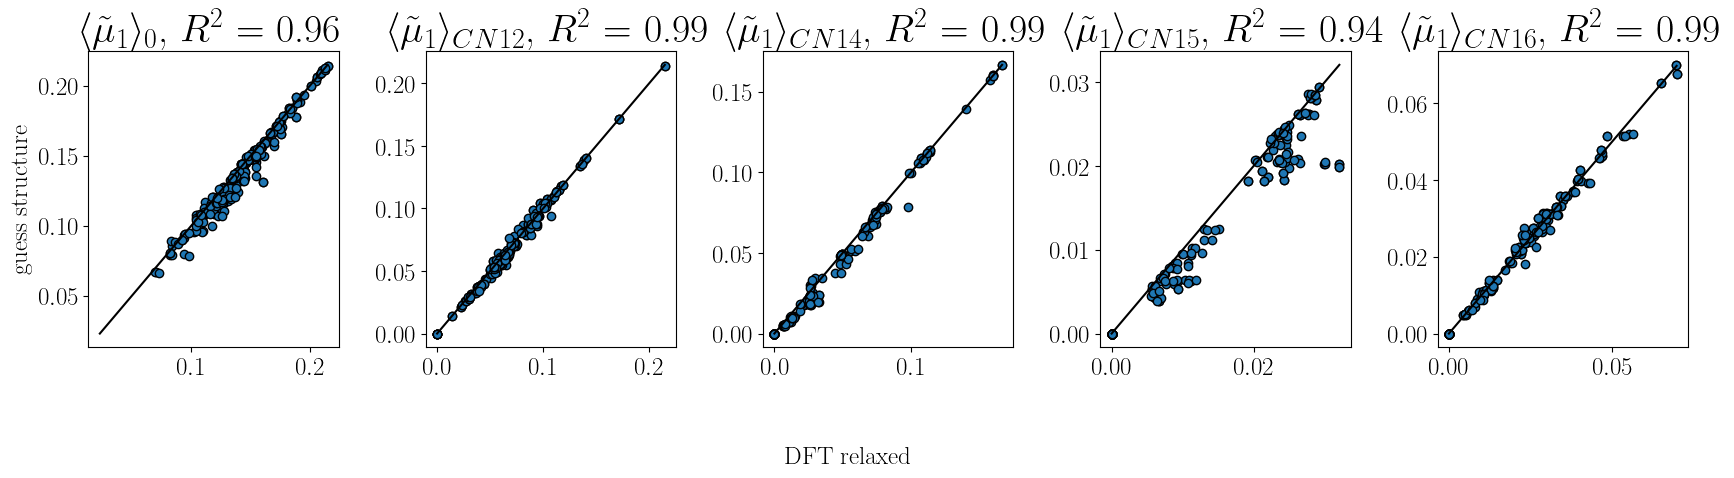

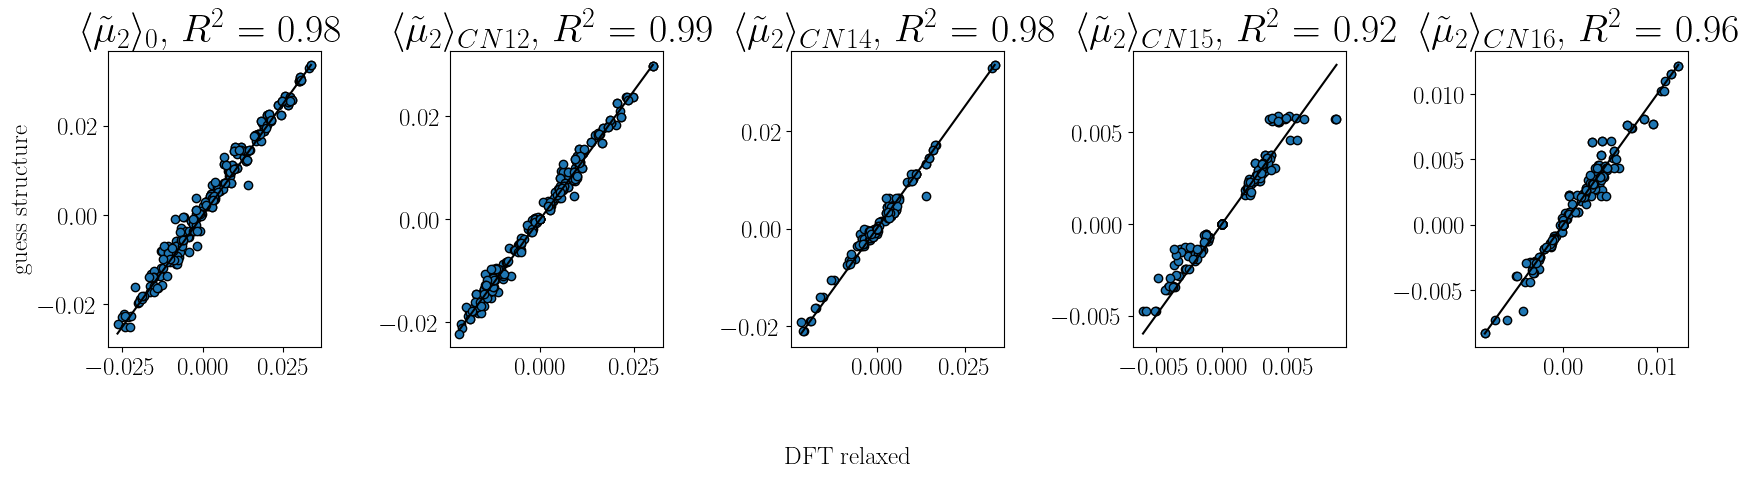

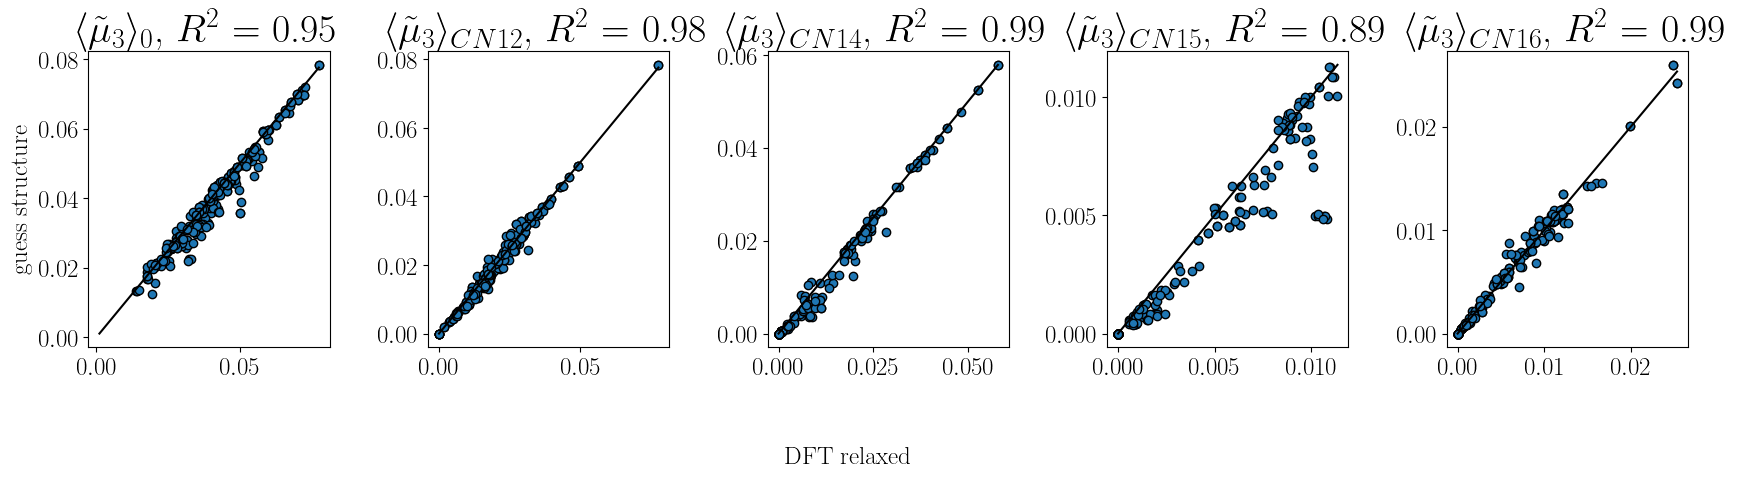

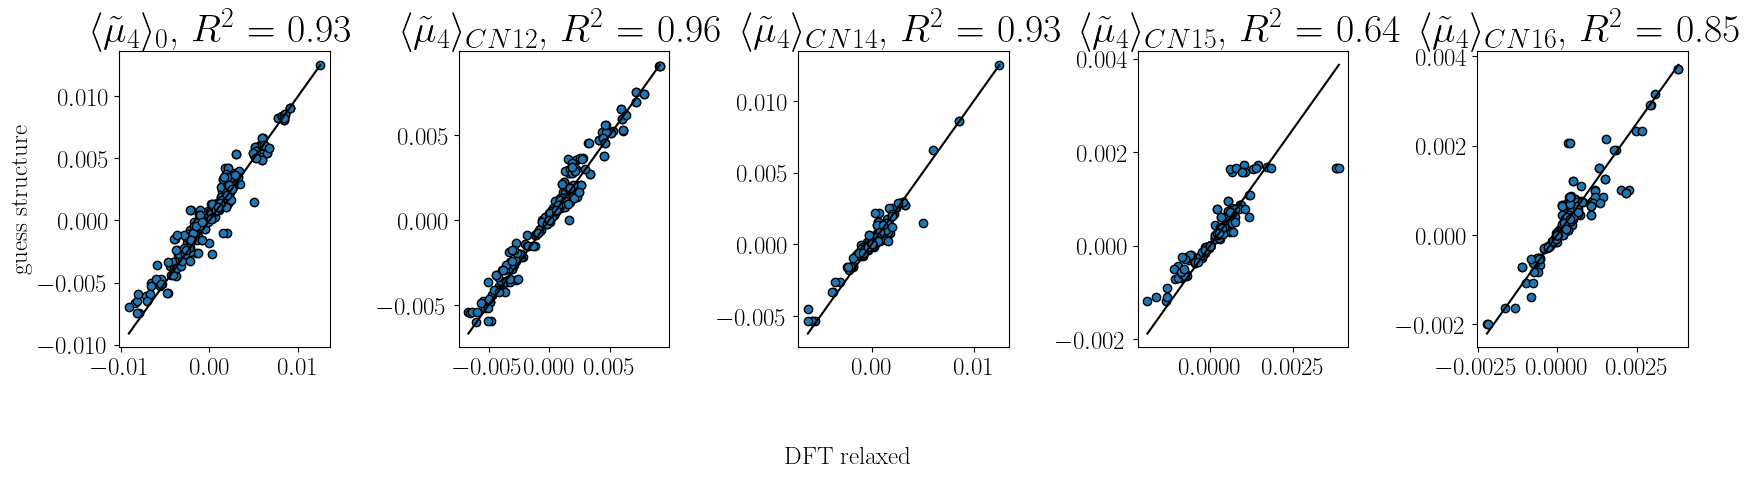

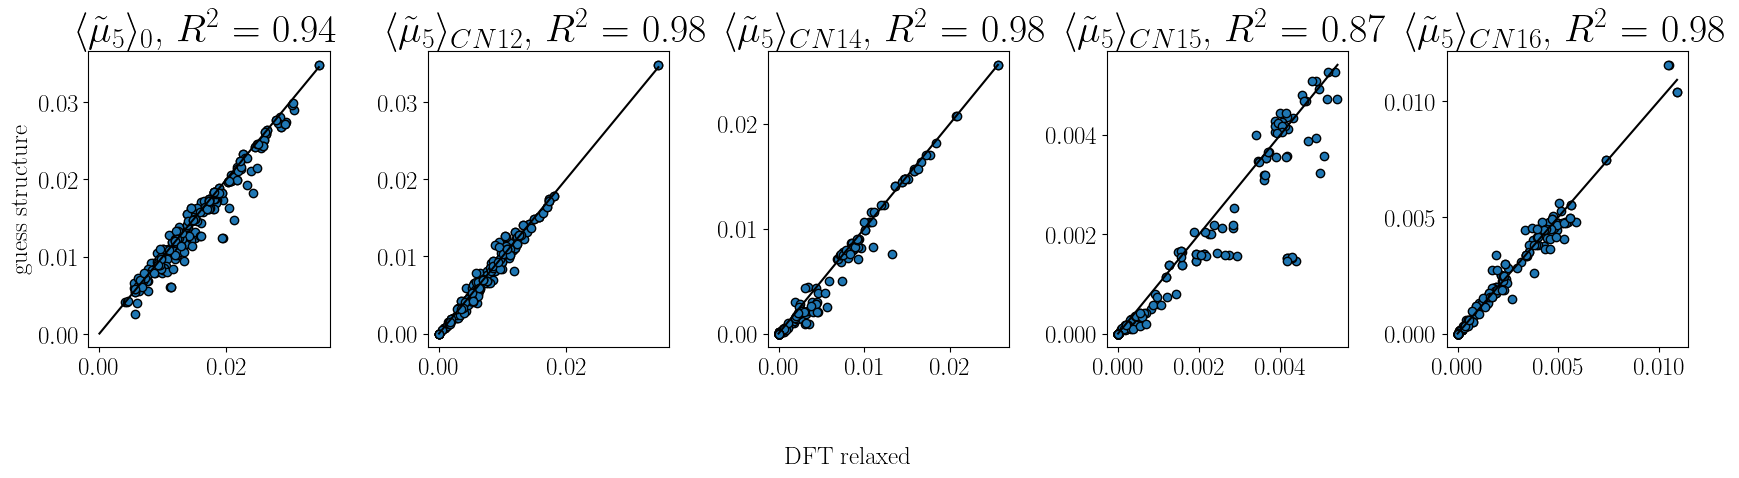

In [99]:
for i in range(6):
    fw, fh = plt.rcParams['figure.figsize']
    fig,axs = plt.subplots(1,5, figsize=(fw*5/2, fh))
    
    for CN, ax in zip(['0','CN12', 'CN14', 'CN15', 'CN16'], axs):
        feature = f'normed_moments_{i}_{CN}'
        x = Moments_RLX[feature]
        y = Moments_INI[feature]
        intersection = x.dropna().index.intersection(y.dropna().index)
        r2 = r2_score(y[intersection], x[intersection])
        ax.scatter(x[intersection], y[intersection] , ec='k')
        proj_0_range = [x.min(), x.max()] 
        ftitle = r'$\langle$'+momentstr+fr'$_{{{i}}} \rangle _{{{CN}}} $'
        ax.plot(proj_0_range, proj_0_range, 'k')
        ax.set_title(ftitle+f', $R^2$ = {r2:.2f}')
    axs[0].set_ylabel('guess structure')
    fig.supxlabel('DFT relaxed', fontsize=18)
    fig.tight_layout()

In [100]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)

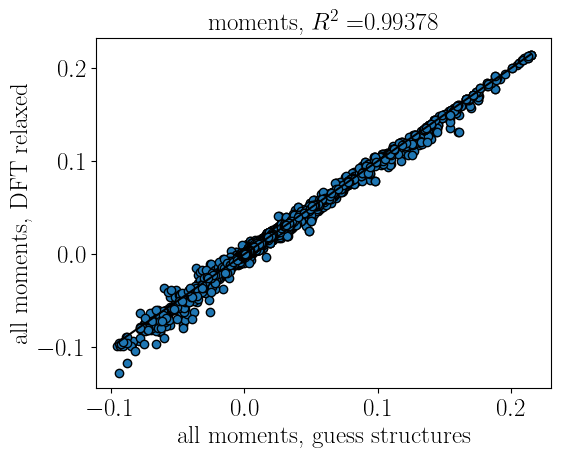

In [101]:
intersection = Moments_RLX.dropna().index.intersection(Moments_INI.dropna().index)
X=    np.ravel(Moments_RLX.loc[intersection])
Y=    np.ravel(Moments_INI.loc[intersection])
fig = plt.figure()
ax = fig.add_subplot([0.25, 0.2, 0.65, 0.7])
ax.scatter(X,Y, ec='k')
therange = [X.min(), X.max()]
r2 = r2_score(X,Y)
ax.set_ylabel('all moments,  DFT relaxed')
ax.set_xlabel('all moments, guess structures')
ax.plot(therange,therange, '-k')
ax.set_title(f'moments, $R^2 = ${r2:.5f}', fontsize=18)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_Moments_rlx-vs-ini.png', dpi=300)


In [102]:
an_RLX = BOPG.resultscnav[rlxmodel].filter(regex='an')
an_INI = BOPG.resultscnav[inimodel].filter(regex='an')

In [103]:
anstr=r'$a$'

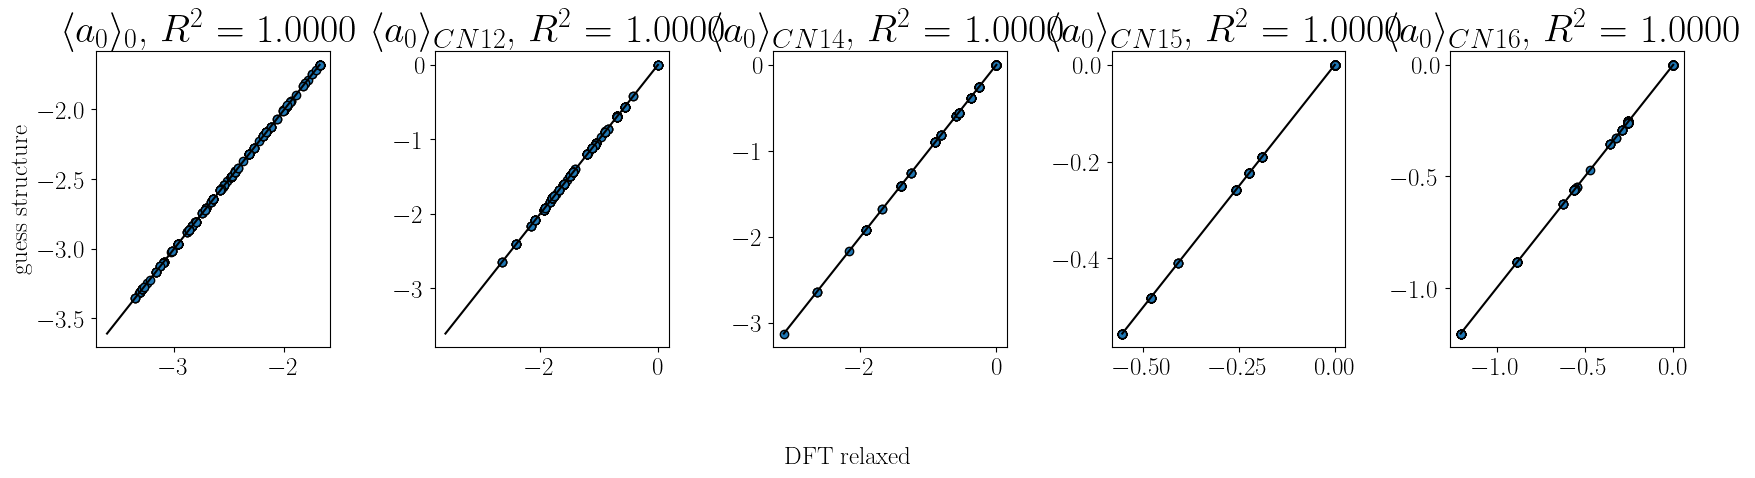

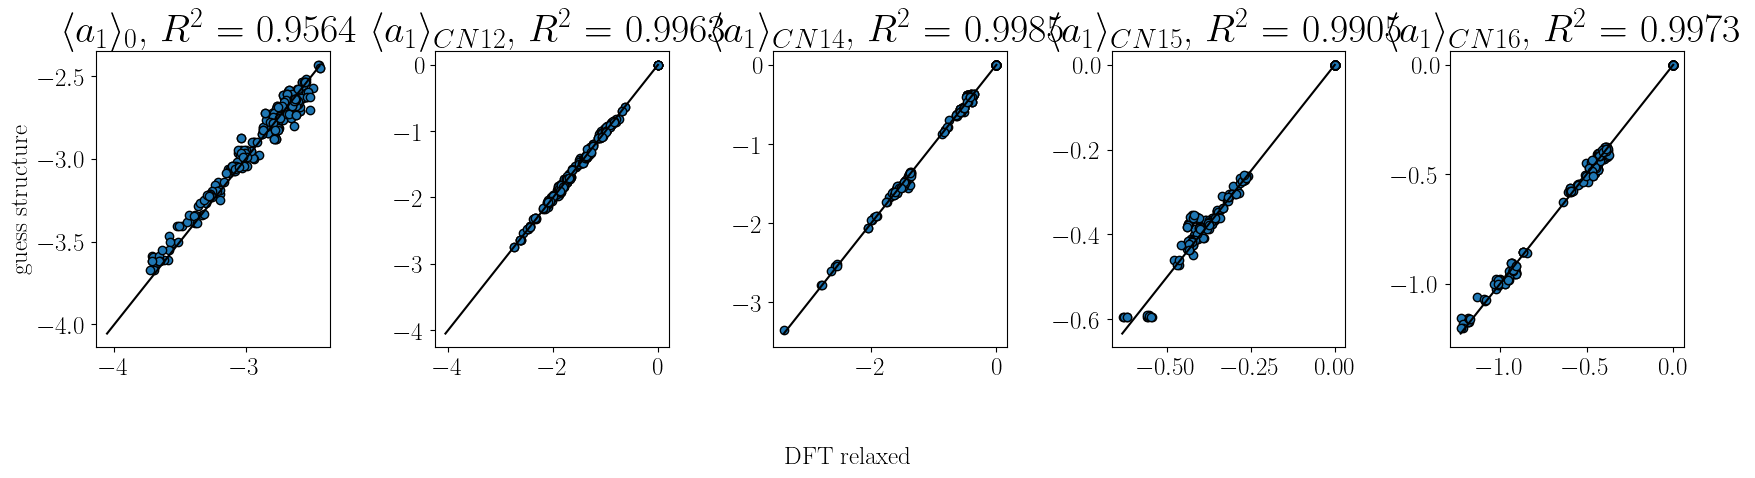

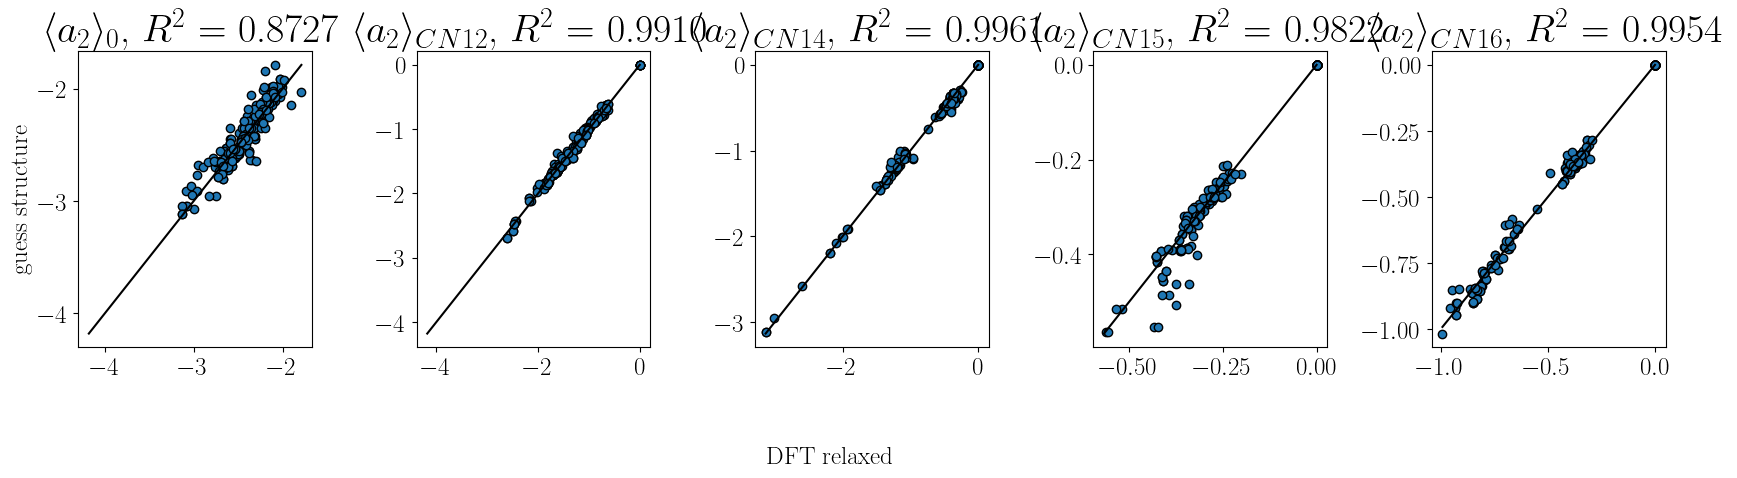

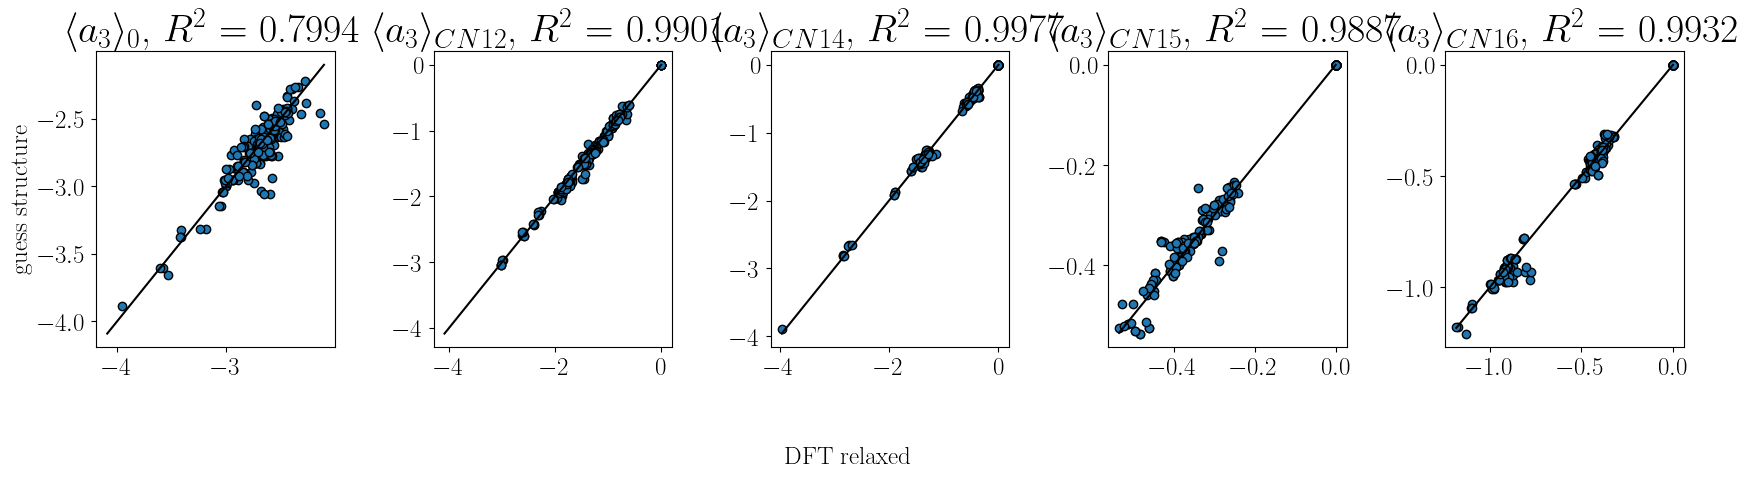

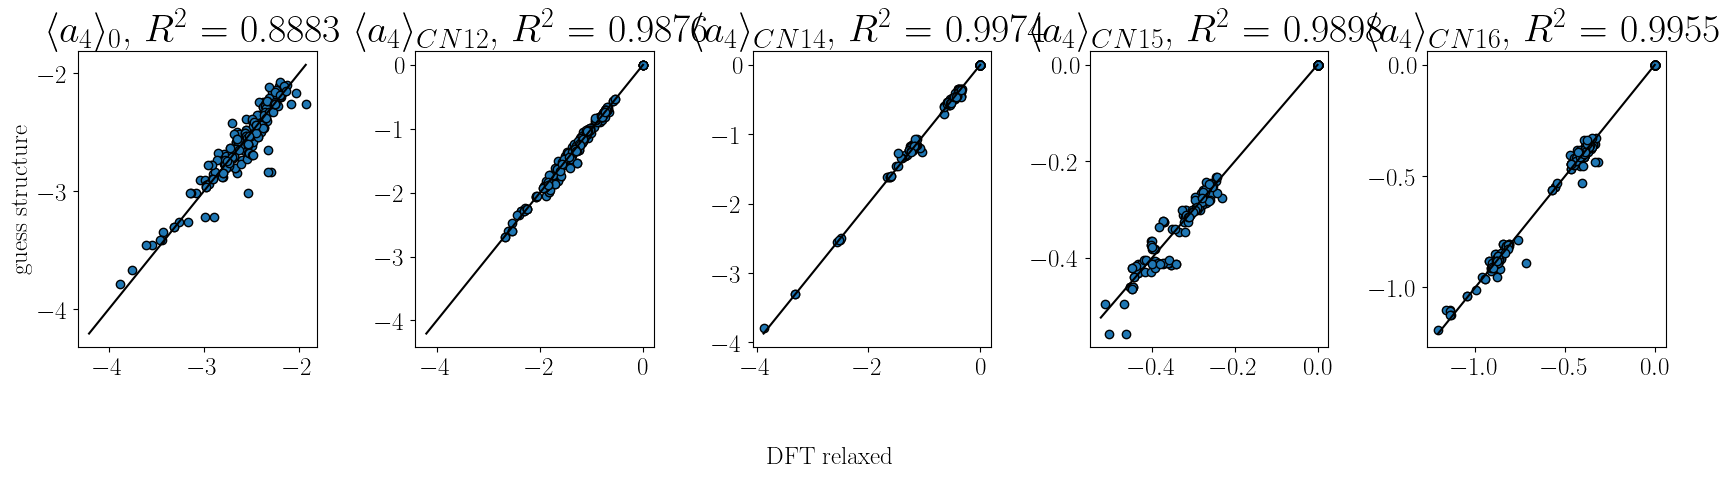

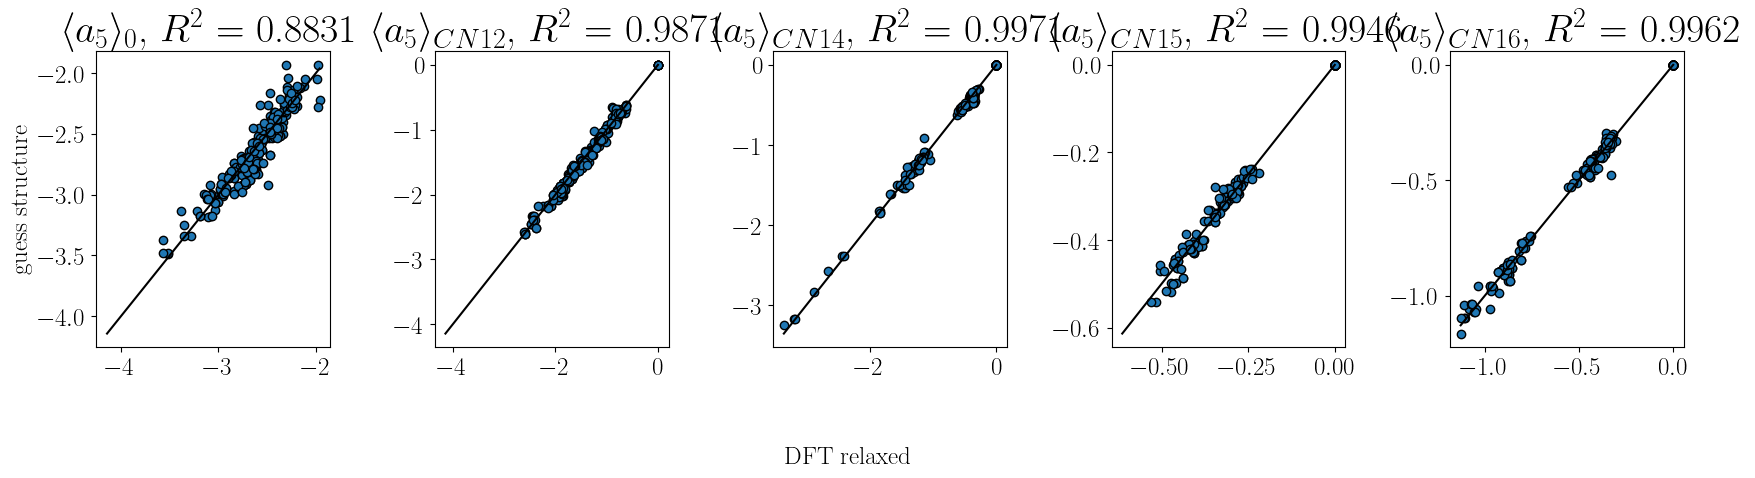

In [104]:
for i in range(6):
    fw, fh = plt.rcParams['figure.figsize']
    fig,axs = plt.subplots(1,5, figsize=(fw*5/2, fh))
    
    for CN, ax in zip(['0','CN12', 'CN14', 'CN15', 'CN16'], axs):
        feature = f'an_{i}_{CN}'
        x = an_RLX[feature]
        y = an_INI[feature]
        intersection = x.dropna().index.intersection(y.dropna().index)
    #    reg = np.poly1d(np.polyfit(x[intersection], y[intersection], 1))
    #    ytilde = reg(x)
        r2 = r2_score(y[intersection], x[intersection])
        ax.scatter(x[intersection], y[intersection] , ec='k')
        proj_0_range = [x.min(), x.max()] 
        ftitle = r'$\langle$'+anstr+fr'$_{{{i}}} \rangle _{{{CN}}} $'
        ax.plot(proj_0_range, proj_0_range, 'k')
        ax.set_title(ftitle+f', $R^2$ = {r2:.4f}')
    axs[0].set_ylabel('guess structure')
    fig.supxlabel('DFT relaxed', fontsize=18)
    fig.tight_layout()

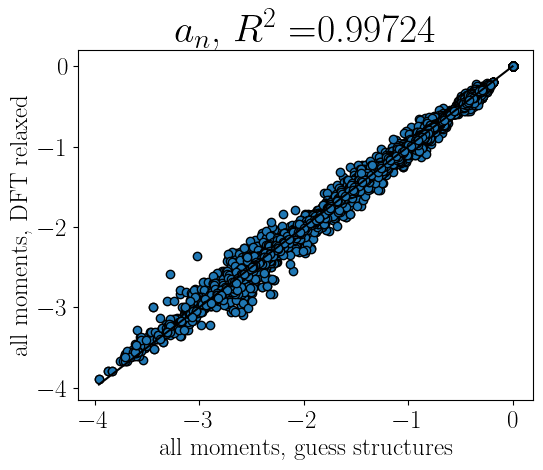

In [105]:
intersection = an_RLX.dropna().index.intersection(an_INI.dropna().index)
X=    np.ravel(an_RLX.loc[intersection])
Y=    np.ravel(an_INI.loc[intersection])
fig = plt.figure()
ax = fig.add_subplot([0.25, 0.2, 0.65, 0.7])
ax.scatter(X,Y, ec='k')
therange = [X.min(), X.max()]
r2 = r2_score(X,Y)
ax.set_ylabel('all moments,  DFT relaxed')
ax.set_xlabel('all moments, guess structures')
ax.plot(therange,therange, '-k')
ax.set_title(fr'$a_{{n}}$, $R^2 = ${r2:.5f}')
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_an_rlx-vs-ini.png', dpi=300)


In [106]:
Y

array([-2.  , -1.12,  0.  , ...,  0.  ,  0.  , -1.05])

# Characterization of BOP features 

In [107]:
for (model, moments, atoms), resultcnav in BOPG.resultscnav.items():
    break

In [108]:
resultcnav.filter(regex='an')

,an_1_0,an_1_CN12,an_1_CN13,an_1_CN14,an_1_CN15,an_1_CN16,an_2_0,an_2_CN12,an_2_CN13,an_2_CN14,...,an_6_CN13,an_6_CN14,an_6_CN15,an_6_CN16,an_7_0,an_7_CN12,an_7_CN13,an_7_CN14,an_7_CN15,an_7_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,-0.214590,-0.129922,0.0,0.000000,0.000000,-0.084668,-0.096692,-0.056773,0.0,0.000000,...,0.0,0.000000,0.000000,-0.077562,-0.340580,-0.229612,0.0,0.000000,0.000000,-0.110968
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-0.189736,-0.092184,0.0,-0.038765,-0.023121,-0.035666,-0.111612,-0.051827,0.0,-0.031159,...,0.0,-0.038941,-0.021672,-0.032231,-0.175194,-0.084110,0.0,-0.046986,-0.017168,-0.026929
Fe_pv2Mo_sv11.mu-BBABB.FM,-0.190229,-0.103259,0.0,-0.023983,-0.023306,-0.039680,-0.123855,-0.038759,0.0,-0.029088,...,0.0,-0.043211,-0.054953,-0.036352,-0.200314,-0.115533,0.0,-0.027392,-0.032086,-0.025304
Fe_pv8Mo_sv22.sigma-BBBAB.NM,-0.194839,-0.065022,0.0,-0.101930,-0.027887,0.000000,-0.045998,-0.032163,0.0,-0.003538,...,0.0,-0.075189,0.004990,0.000000,-0.108002,-0.018488,0.0,-0.071480,-0.018035,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,-0.190229,-0.103259,0.0,-0.023983,-0.023306,-0.039680,-0.123855,-0.038759,0.0,-0.029088,...,0.0,-0.043211,-0.054953,-0.036352,-0.200314,-0.115533,0.0,-0.027392,-0.032086,-0.025304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,-0.162887,0.000000,0.0,-0.162887,0.000000,0.000000,-0.053323,0.000000,0.0,-0.053323,...,0.0,-0.275346,0.000000,0.000000,-0.314827,0.000000,0.0,-0.314827,0.000000,0.000000
Mo_sv8.A15.NM,-0.164698,-0.040306,0.0,-0.124392,0.000000,0.000000,0.055338,0.024335,0.0,0.031003,...,0.0,-0.023093,0.000000,0.000000,0.047891,0.016056,0.0,0.031835,0.000000,0.000000
Mo_sv1.fcc.NM,-0.164724,-0.164724,0.0,0.000000,0.000000,0.000000,-0.249399,-0.249399,0.0,0.000000,...,0.0,0.000000,0.000000,0.000000,-0.263992,-0.263992,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,-0.200590,-0.139570,0.0,0.000000,0.000000,-0.061021,-0.088598,-0.062914,0.0,0.000000,...,0.0,0.000000,0.000000,-0.083450,-0.326748,-0.197970,0.0,0.000000,0.000000,-0.128777


In [109]:
def make_corr_matrix(resultscnav, feature_root, model, avn='0'):
    correlation = pd.concat([
        resultscnav.filter(regex=f'{feature_root}_.*_{avn}'), 
                    BOPG.BS[BOPG.target_case]], axis=1).corr().abs()
    return correlation

In [110]:
def plot_target_correlations(feature, avn='0'):
    fig = plt.figure(figsize = (6,4))
    i = 0
    axs = []
    for (model, moments, atoms), results in BOPG.resultscnav.items():
        if atoms == 'relaxed':
            continue
        i += 1
        correlation_an = make_corr_matrix(results, feature, model, avn)
        correlations = correlation_an[BOPG.target_case][correlation_an.index != BOPG.target_case]
        if i>1:
            axs.append( fig.add_axes([i-1+0.05, 0.15, 0.95,0.7] ) )
            axs[-1].sharey = axs[0]
            axs[-1].set_yticklabels([])
        else:
            axs.append( fig.add_axes([i-1+0.05, 0.15, 0.95,0.7]))
        axs[-1].set_title(model)
        axs[-1].barh(correlations.index,correlations)
    fig.supxlabel(f'correlation to {BOPG.target_case}',x=1.5, y = -0.05)
    return fig, axs

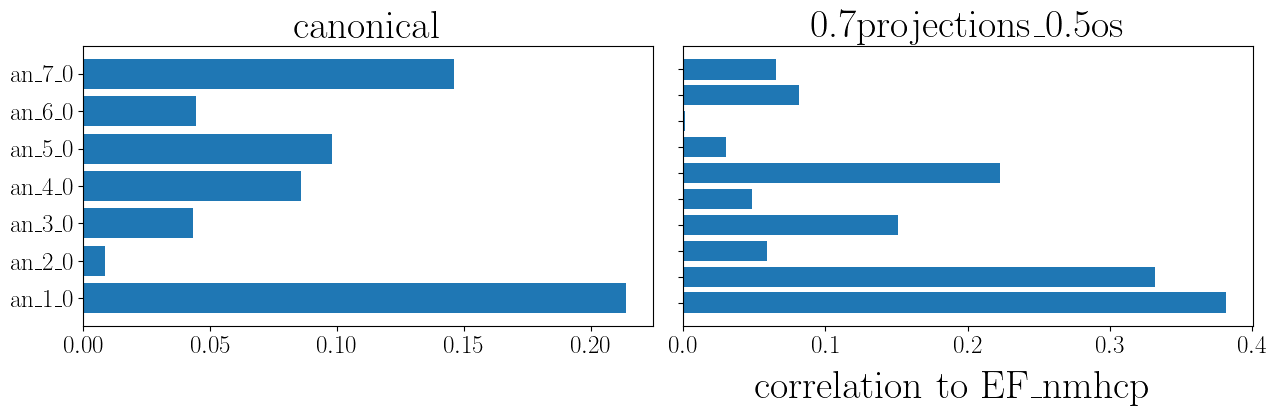

In [111]:
fig, axs = plot_target_correlations('an')

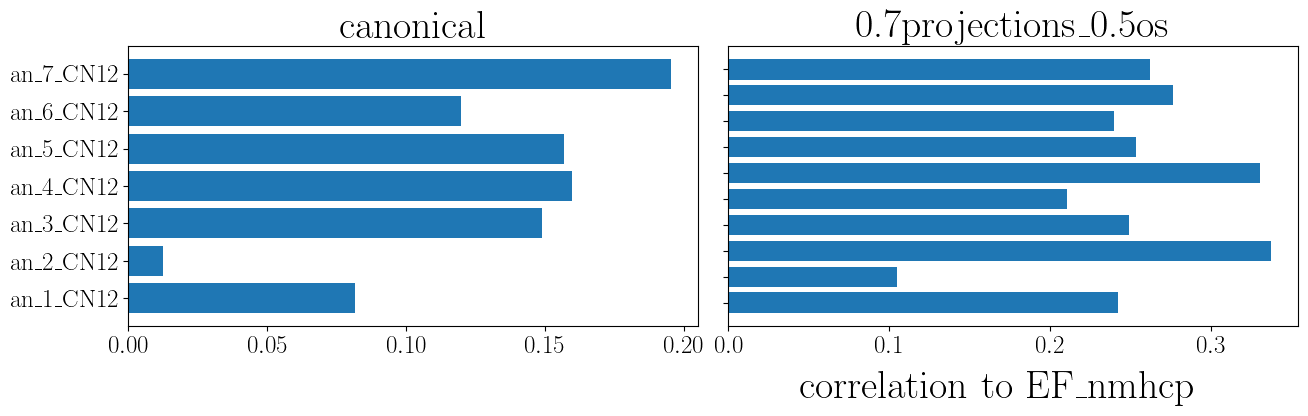

In [112]:
fig, axs = plot_target_correlations('an', 'CN12')

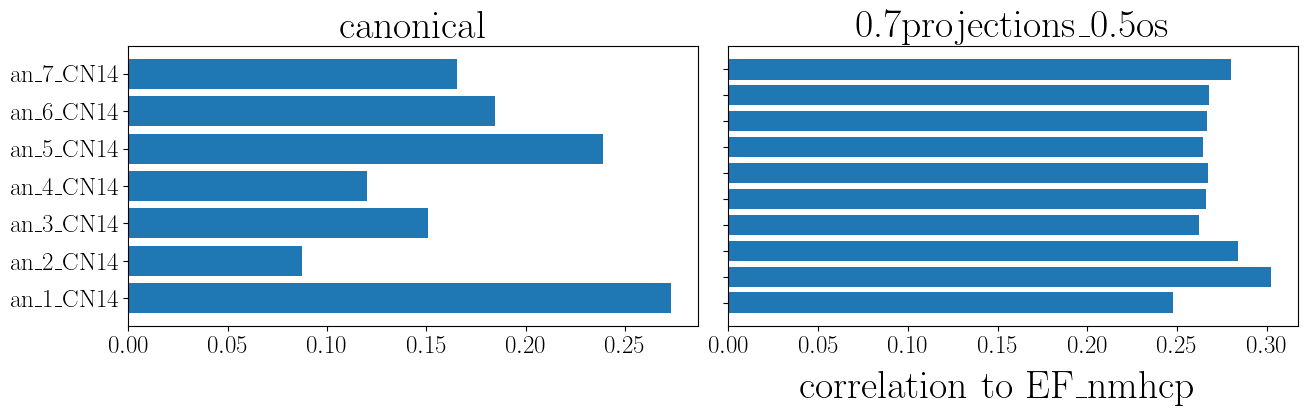

In [113]:
fig, axs = plot_target_correlations('an', 'CN14')

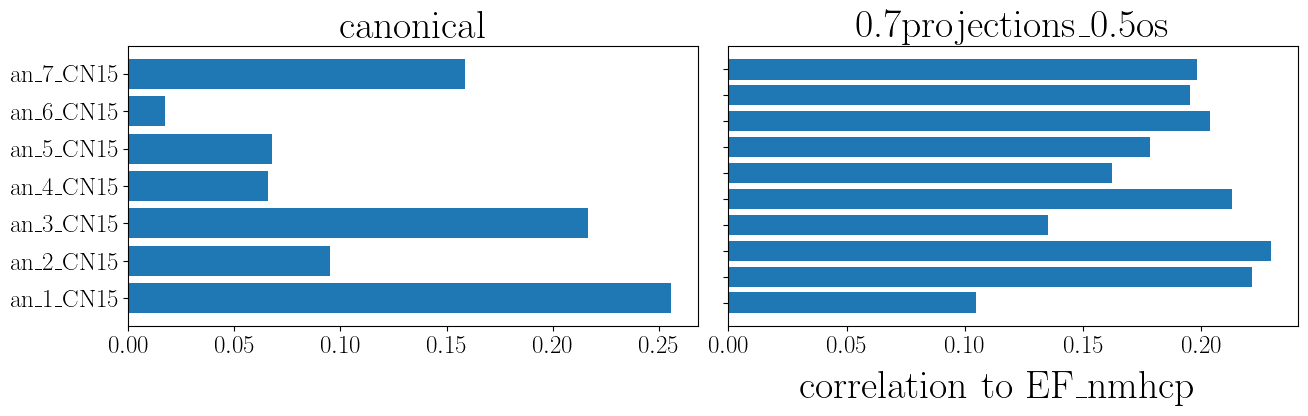

In [114]:
fig, axs = plot_target_correlations('an', 'CN15')

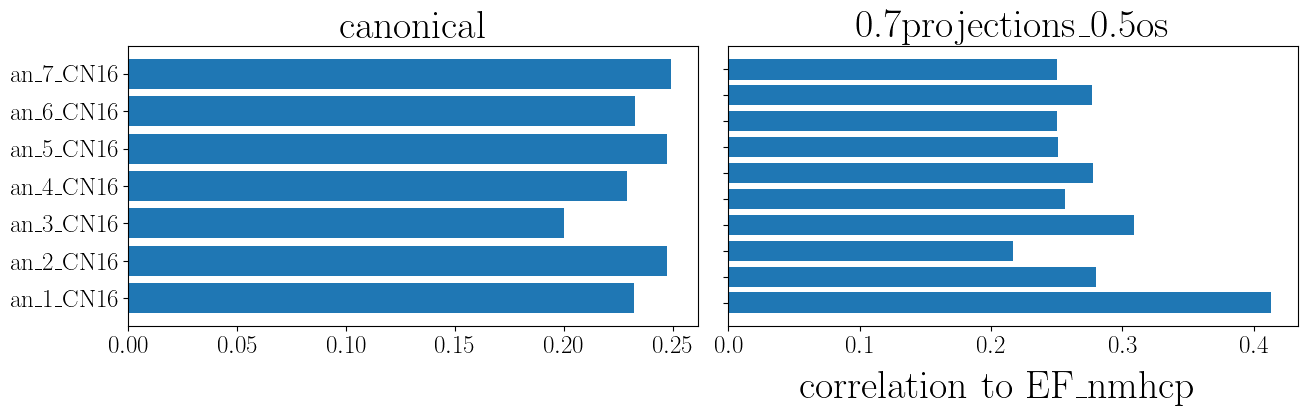

In [115]:
fig, axs = plot_target_correlations('an', 'CN16')

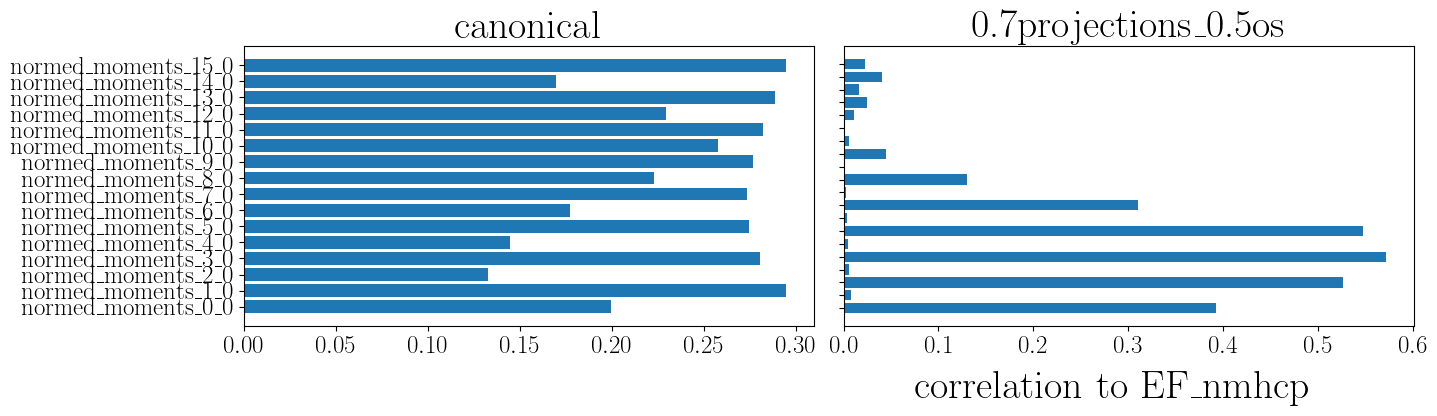

In [116]:
fig, axs = plot_target_correlations('normed_moments')

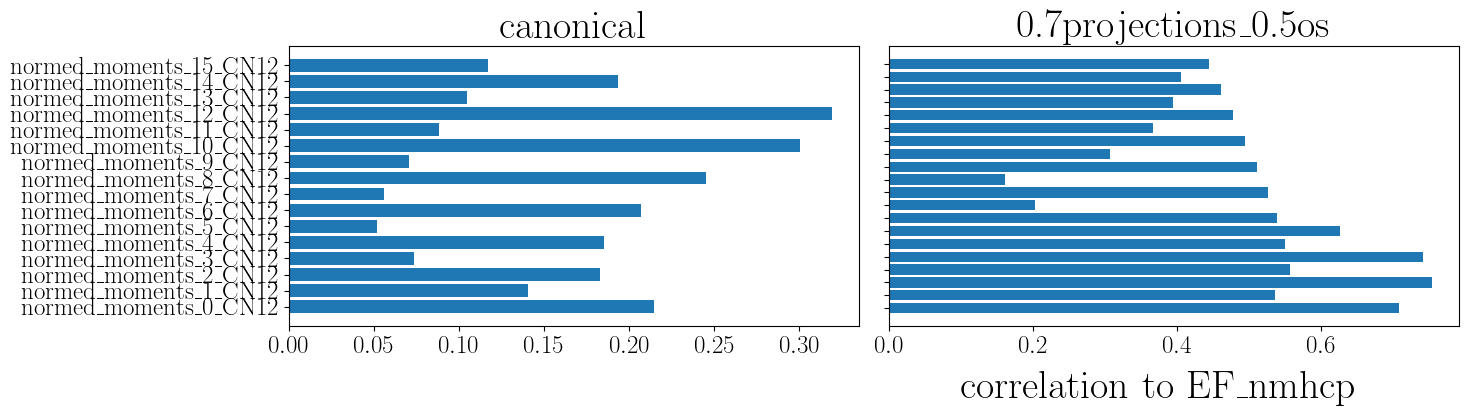

In [117]:
fig, axs = plot_target_correlations('normed_moments','CN12')

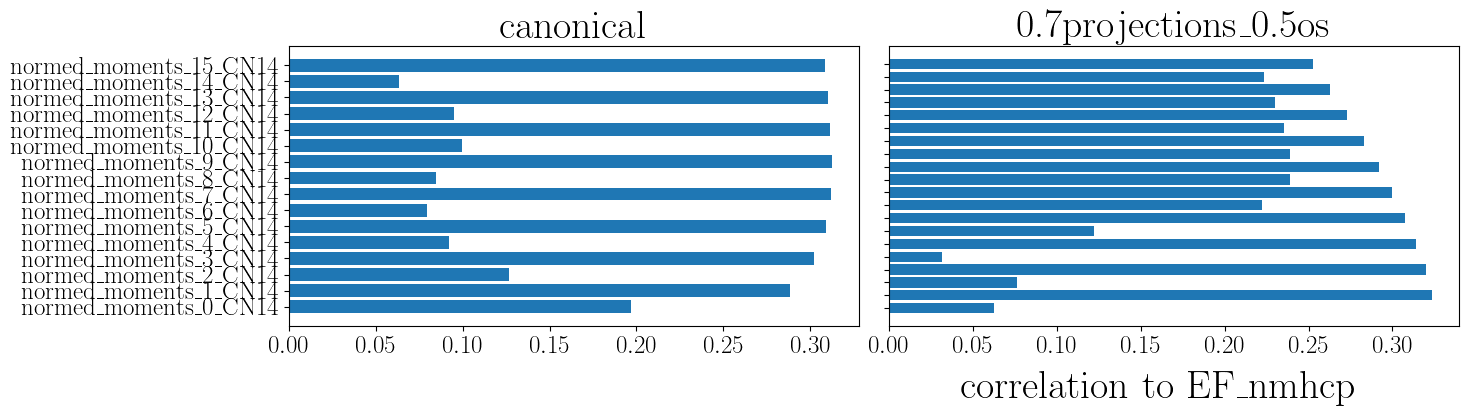

In [118]:
fig, axs = plot_target_correlations('normed_moments','CN14')

In [119]:
BOPG.resultscnav.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

Text(0.02, 0.5, 'bn_1_0')

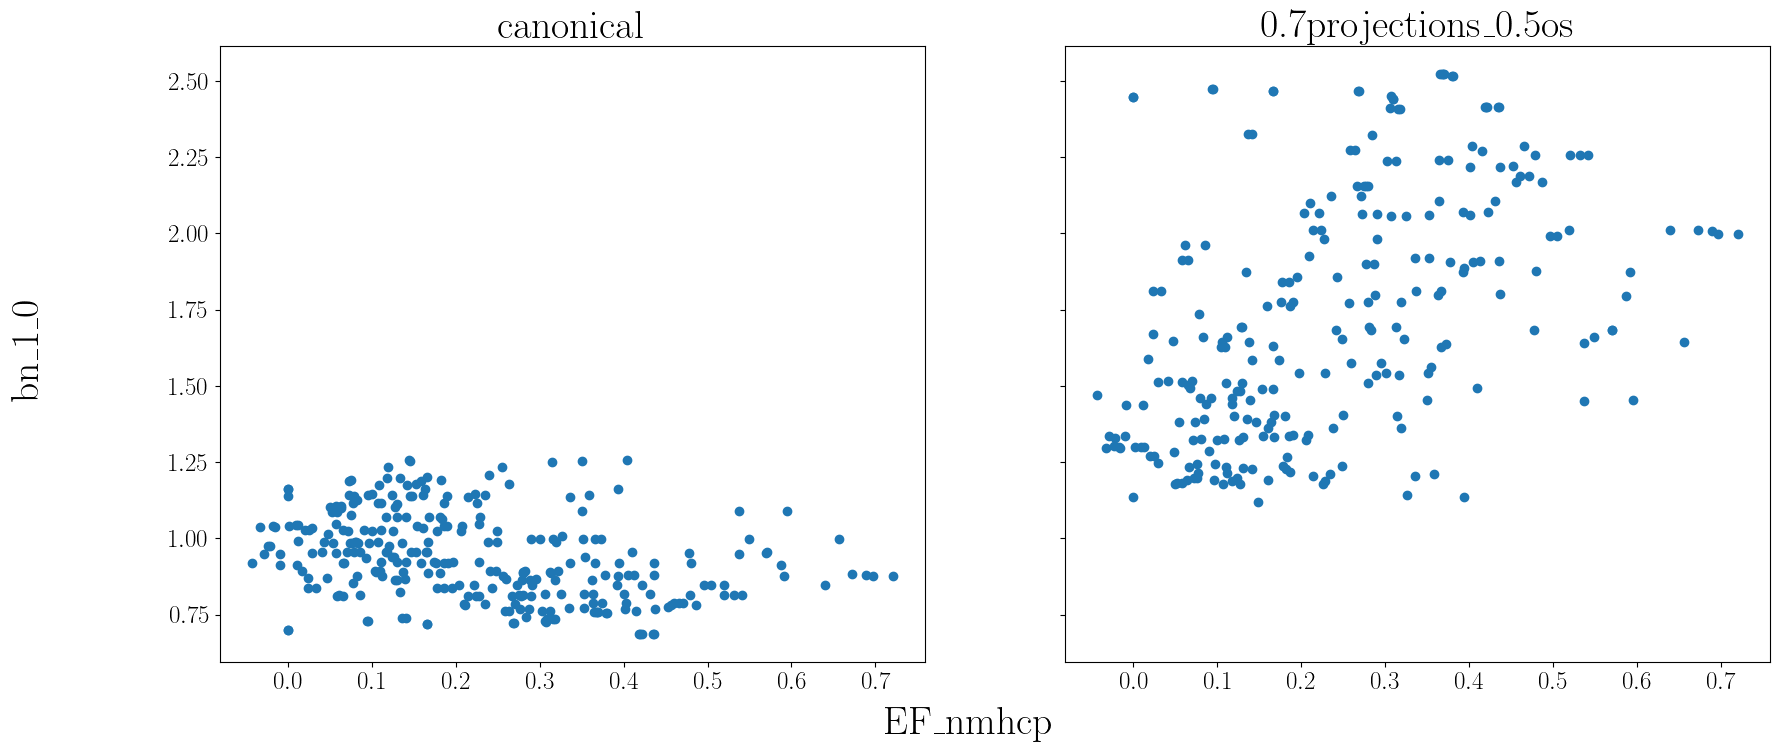

In [120]:
descriptor = 'bn_1_0'
fig, axes = plt.subplots(1, int(len(BOPG.resultscnav)/2), sharex=True,  sharey=True, figsize=(20, 8))
i = 0
for (model, globalmoments, atoms) , resultcnav in BOPG.resultscnav.items():
    if atoms == 'relaxed':
        continue
    i += 1
    intersection = resultcnav[descriptor].dropna().index.intersection(BOPG.BS[BOPG.target_case].dropna().index)
    axes[i-1].scatter( BOPG.BS[BOPG.target_case][intersection],resultcnav[descriptor][intersection] )#.filter(regex='U')
    axes[i-1].set_title(model.replace('0.7projections_0.5os_',''))
fig.supxlabel(BOPG.target_case)
fig.supylabel(descriptor)

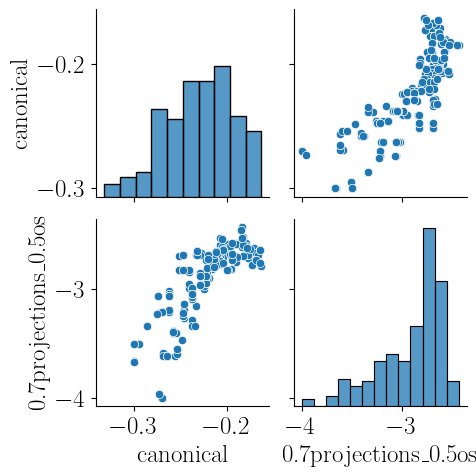

In [121]:
descriptor = 'an_1_0'
df_descriptor = pd.DataFrame([])
for (model, globalmoments, atoms) , resultcnav in BOPG.resultscnav.items():
    if atoms == 'relaxed':
        continue
    i += 1
    add = resultcnav[descriptor]
    add.name = model.replace('0.7projections_0.5os_','')
    df_descriptor = pd.concat([df_descriptor,add], axis = 1)
g = sns.pairplot(df_descriptor )


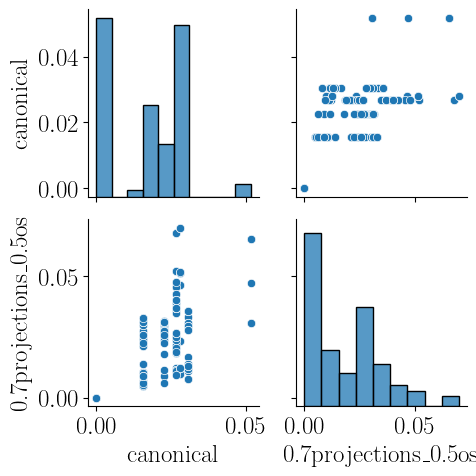

In [122]:
descriptor = 'normed_moments_1_CN16'
df_descriptor = pd.DataFrame([])
for (model, globalmoments, atoms) , resultcnav in BOPG.resultscnav.items():
    if atoms == 'relaxed':
        continue
    i += 1
    add = resultcnav[descriptor]
    add.name = model.replace('0.7projections_0.5os_','')
    df_descriptor = pd.concat([df_descriptor,add], axis = 1)
g = sns.pairplot(df_descriptor )


In [123]:
BOPG.resultscnav

{('canonical',
  16,
  'initial'):                                  U_bond_atom_list_1_0   
 Fe_pv4Mo_sv20.C36-ABBBB.FM                  -6.925199  \
 Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM             -7.069580   
 Fe_pv2Mo_sv11.mu-BBABB.FM                   -6.601047   
 Fe_pv8Mo_sv22.sigma-BBBAB.NM                -6.958838   
 Fe_pv2Mo_sv11.mu-BBBBA.NM                   -6.566157   
 ...                                               ...   
 Mo_sv1.bcc.NM                               -3.130925   
 Mo_sv8.A15.NM                               -5.978096   
 Mo_sv1.fcc.NM                               -2.941773   
 Mo_sv6.C15.NM                               -5.893929   
 Mo_sv53.R.FM                                      NaN   
 
                                  U_bond_atom_list_1_CN12   
 Fe_pv4Mo_sv20.C36-ABBBB.FM                     -6.050627  \
 Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM                -2.079584   
 Fe_pv2Mo_sv11.mu-BBABB.FM                      -2.125589   
 Fe_pv8Mo_sv22.sigma-BBB

<Axes: >

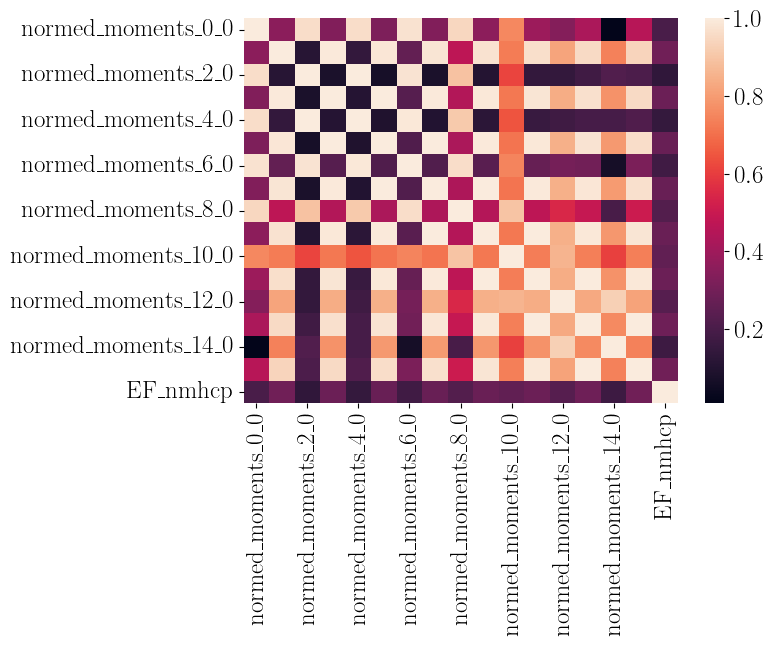

In [124]:
correlation_normed_moments = make_corr_matrix(BOPG.resultscnav[('canonical', 16, 'initial')], 'normed_moments', 'canonical')
sns.heatmap(correlation_normed_moments)

In [125]:
BOPG.resultscnav.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

(<Axes: >,)

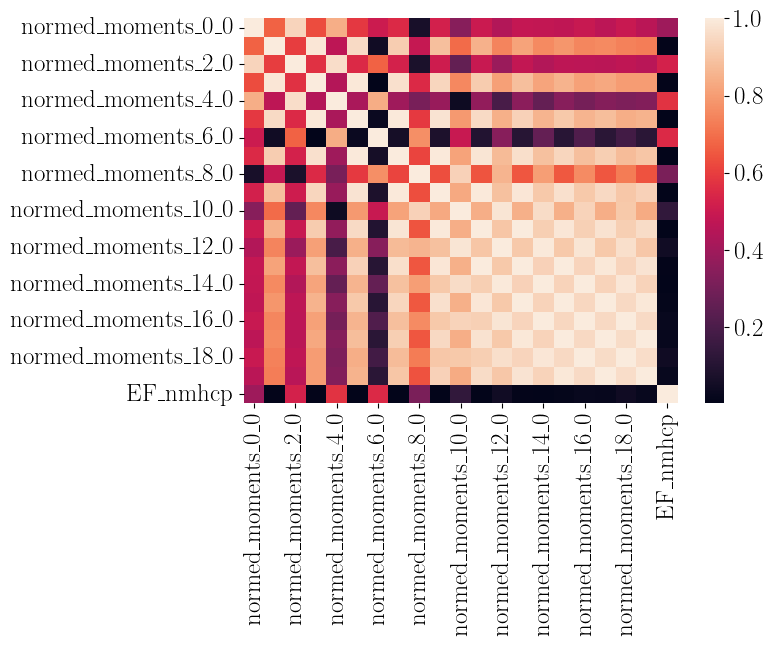

In [126]:
correlation_normed_moments = make_corr_matrix(BOPG.resultscnav[('0.7projections_0.5os', 16, 'initial')], 'normed_moments', '0.7projections_0.5os')
sns.heatmap(correlation_normed_moments),

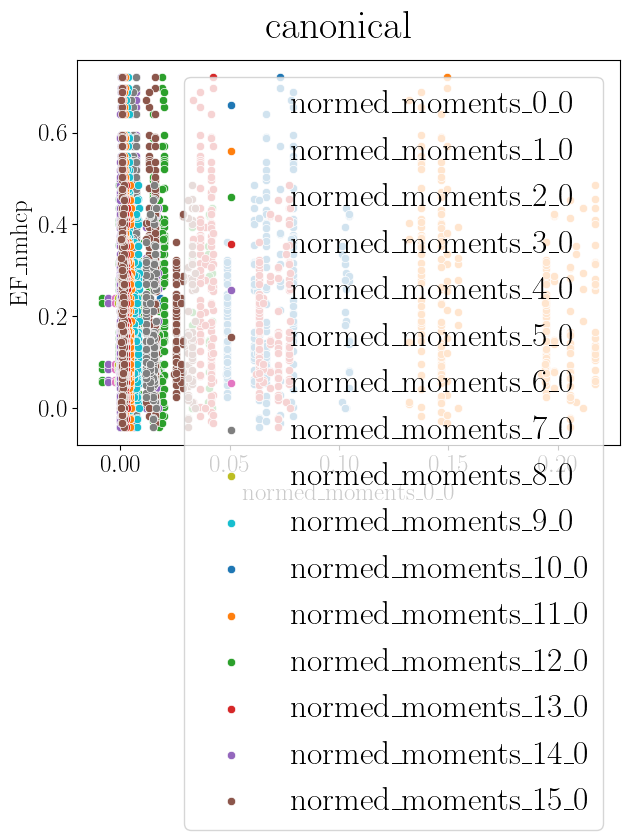

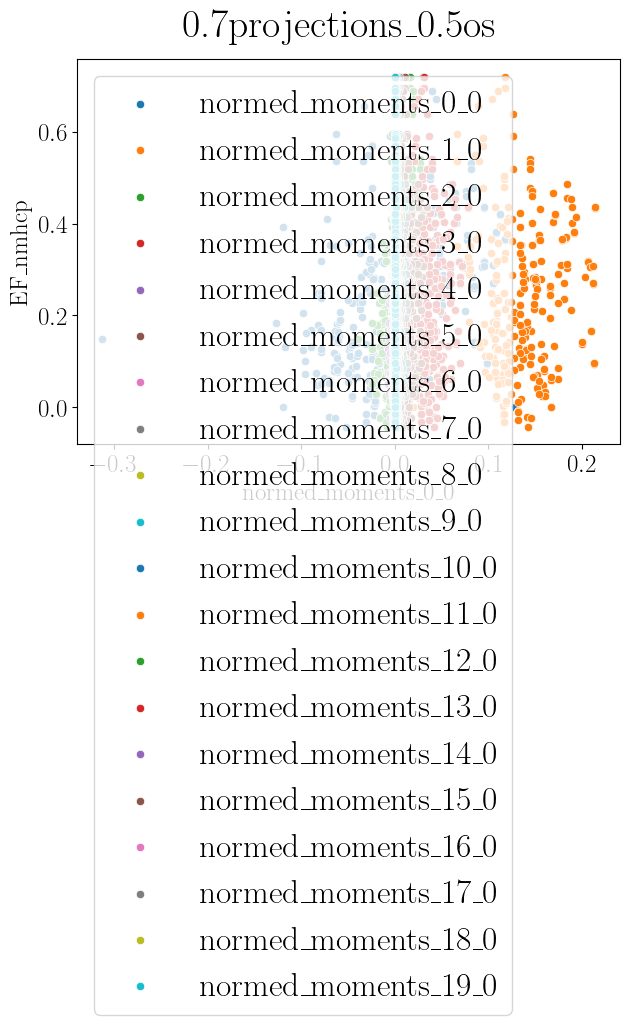

In [132]:
for (model, moments, atoms),results in BOPG.resultscnav.items():
    if atoms == 'relaxed':
        continue
    fig, ax = plt.subplots()
    for label, an in results.filter(regex='normed_moments_.*_0').items():
        intersection = an.dropna().index.intersection(BS[target_case].dropna().index)
        sns.scatterplot(x=an[intersection],y=BS[target_case][intersection], ax = ax, label=label)
    fig.suptitle(model)

In [133]:
from sklearn.preprocessing import StandardScaler

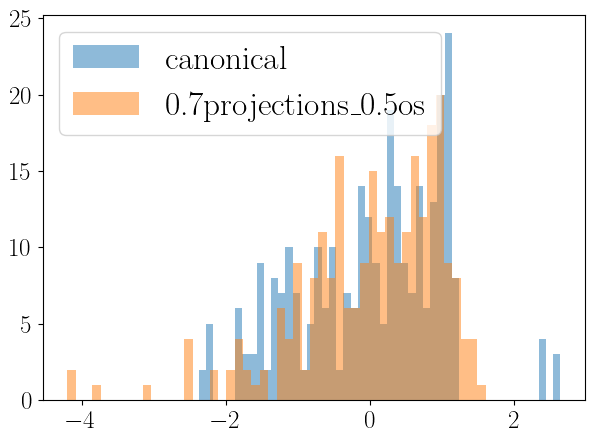

In [135]:
fig, ax = plt.subplots()
for (model, moments, atoms),results in BOPG.resultscnav.items():
    if atoms == 'relaxed':
        continue
    scaler = StandardScaler()
    scaled = scaler.fit_transform(results.an_7_0.values.reshape(-1,1))
    ax.hist(scaled, label = model, bins=50, alpha = 0.5)
ax.legend()

In [148]:
def comparefeatures(featurename, featuresymbol, ax = None, suffix = '_0', which = [None]):
    plotfeature = f'{featurename}{suffix}'
    symbol = fr'$\langle {featuresymbol} \rangle $'
    return_ax_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        return_ax_fig = True
    ensamble = []
    for model, thisresultcnav in BOPG.resultscnav.items():
        if model not in which:
            continue
        ensamble.append(thisresultcnav[plotfeature] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for model, result in resultscnav.items():
        if model not in which:
            continue
        ax.hist(result[plotfeature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax.set_xlabel(symbol)
    ax.legend()
    ax.set_ylabel('Counts')
    if return_ax_fig:
        return fig, ax

In [149]:
def compare_many_orders(featurename, featuresymbol, norders = 3, which = ['projections']):
    fig, axes = plt.subplots(1, norders, figsize=(7*norders, 5), sharey=True)
    for i, ax in enumerate(axes):
        if 'sos' not in featurename:
            tfeaturename = featurename+f'_{i+1}'
            tfeaturesymbol = featuresymbol+f'_{i+1}'
            comparefeatures(tfeaturename, tfeaturesymbol, which=which,  ax=ax)
            ax.legend([]).remove()
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5,1.005))
    fig.subplots_adjust(bottom=0.2) 
    [ax.set_ylabel('') for ax in axes[1:]]
#    fig.tight_layout()
    return fig, axes
    

## Shape factors 

In [145]:
BOPG.resultscnav.keys()

dict_keys([('canonical', 16, 'initial'), ('canonical', 16, 'relaxed'), ('0.7projections_0.5os', 16, 'initial'), ('0.7projections_0.5os', 16, 'relaxed')])

In [146]:
BOPG.resultscnav[('canonical', 16,'initial')].filter(regex='sf')

,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,1.081732,1.156282,0.0,0.000000,0.000000,0.901327
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,1.192249,1.343511,0.0,1.139857,0.956735,0.947607
Fe_pv2Mo_sv11.mu-BBABB.FM,1.071112,1.222570,0.0,0.902495,0.748342,1.001885
Fe_pv8Mo_sv22.sigma-BBBAB.NM,1.224173,1.311938,0.0,1.187306,1.155462,0.000000
Fe_pv2Mo_sv11.mu-BBBBA.NM,1.071112,1.222570,0.0,0.902495,0.748342,1.001885
...,...,...,...,...,...,...
Mo_sv1.bcc.NM,1.261308,0.000000,0.0,1.261308,0.000000,0.000000
Mo_sv8.A15.NM,1.195488,1.177466,0.0,1.201725,0.000000,0.000000
Mo_sv1.fcc.NM,1.140028,1.140028,0.0,0.000000,0.000000,0.000000
Mo_sv6.C15.NM,1.069389,1.032622,0.0,0.000000,0.000000,1.135754


# Correlations

In [ ]:
BS = pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')

In [ ]:
ax = sns.scatterplot(data = resultscnav['canonical'][resultscnav['canonical']['bn_2_0']<4], x = 'an_1_0', y ='bn_2_0')
ax = sns.scatterplot(data = resultscnav['projections'][resultscnav['projections']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['projections_os'][resultscnav['projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['0.6projections_os'][resultscnav['0.6projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['0.7projections_os'][resultscnav['0.7projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax = sns.scatterplot(data = resultscnav['0.8projections_os'][resultscnav['0.8projections_os']['bn_2_0']<6], x = 'an_1_0', y ='bn_2_0', ax = ax)
ax.legend(['canonical', 'projections', 'projections_os', '0.6projections_os', '0.7projections_os','0.8projections_os'])

##  shape-factors

In [ ]:
BS.index.difference(resultscnav['canonical'].index)

In [ ]:
resultscnav['canonical'].index.difference(BS.index)

In [ ]:
import pdb

In [ ]:
def target_correlation_scatters (featurename, featuresymbol, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    selection={model: BS.index.intersection(result[featurename].index) for model, result in resultscnav.items()}
    [sns.scatterplot(x=resultscnav[model][featurename].loc[selection[model]], y = BS[target_case][selection[model]], ax = ax) for model in models]
    ax.set_ylabel(r'$\Delta E_f$')
    ax.set_xlabel(featuresymbol)
    ax.legend(models)
    return ax

In [ ]:
def correlation_vs_order(feature, featuresymbol, order=[1,2,3,4]):
    fig, axes = plt.subplots(1, len(order),  sharey=True, figsize=(7*4, 5))
    for i, ax in enumerate(axes):
        thisfeaturename = f'{feature}_{order[i]}_0'
        thisfeaturesymbol = f'${featuresymbol}_{order[i]}$'
        ax = target_correlation_scatters(thisfeaturename, thisfeaturesymbol, ax=ax)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(labels), loc='upper center')

# Compute pearson correlations explicitly 

In [152]:
model = 'canonical'

In [153]:
BS[target_case] = BS[target_case].astype(float)

In [155]:
BOPG.resultscnav[( 'canonical', 16, 'initial' )].astype(float) #['U_bind'].astype(float).corr(BS['E0'])

,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,...,Binf_0_CN15,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom
Fe_pv4Mo_sv20.C36-ABBBB.FM,-6.925199,-6.050627,0.0,0.000000,0.000000,-0.874571,0.689619,0.571110,0.0,0.000000,...,0.000000,0.390118,1.081732,1.156282,0.0,0.000000,0.000000,0.901327,-82.472282,-84.309469
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-7.069580,-2.079584,0.0,-0.750946,-0.317244,-3.921805,0.690493,0.433446,0.0,0.138158,...,0.098697,0.137907,1.192249,1.343511,0.0,1.139857,0.956735,0.947607,-186.101697,-189.259613
Fe_pv2Mo_sv11.mu-BBABB.FM,-6.601047,-2.125589,0.0,-3.588088,-0.477620,-0.409750,0.647479,0.470223,0.0,0.066167,...,0.159925,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731
Fe_pv8Mo_sv22.sigma-BBBAB.NM,-6.958838,-1.238417,0.0,-5.296760,-0.423661,0.000000,0.658999,0.243336,0.0,0.346571,...,0.124251,0.000000,1.224173,1.311938,0.0,1.187306,1.155462,0.000000,-106.073592,-106.249550
Fe_pv2Mo_sv11.mu-BBBBA.NM,-6.566157,-2.087629,0.0,-0.512510,-0.374860,-3.591159,0.647479,0.470223,0.0,0.066167,...,0.166503,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,-3.130925,0.000000,0.0,-3.130925,0.000000,0.000000,0.491648,0.000000,0.0,0.491648,...,0.000000,0.000000,1.261308,0.000000,0.0,1.261308,0.000000,0.000000,-3.130925,-3.130925
Mo_sv8.A15.NM,-5.978096,-3.583571,0.0,-2.394525,0.000000,0.000000,0.531115,0.136149,0.0,0.394967,...,0.000000,0.000000,1.195488,1.177466,0.0,1.201725,0.000000,0.000000,-25.446069,-25.453952
Mo_sv1.fcc.NM,-2.941773,-2.941773,0.0,0.000000,0.000000,0.000000,0.471662,0.471662,0.0,0.000000,...,0.000000,0.000000,1.140028,1.140028,0.0,0.000000,0.000000,0.000000,-2.941774,-2.941774
Mo_sv6.C15.NM,-5.893929,-4.637664,0.0,0.000000,0.000000,-1.256266,0.595096,0.348279,0.0,0.000000,...,0.000000,0.373010,1.069389,1.032622,0.0,0.000000,0.000000,1.135754,-19.164680,-19.566188


In [172]:
TargetCorrelations =  {}
for keys, results in BOPG.resultscnav.items() :
    TargetCorrelations[keys] = results.corrwith(BS[target_case]).dropna().abs().sort_values(ascending=False)

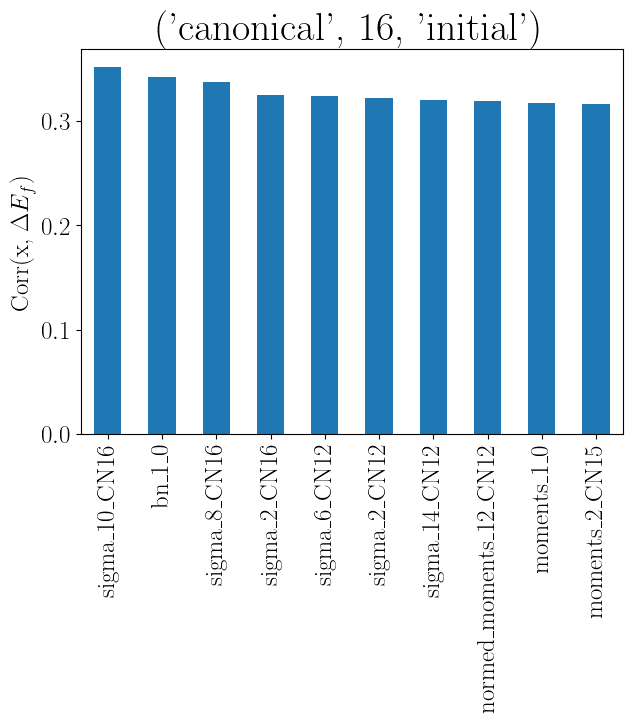

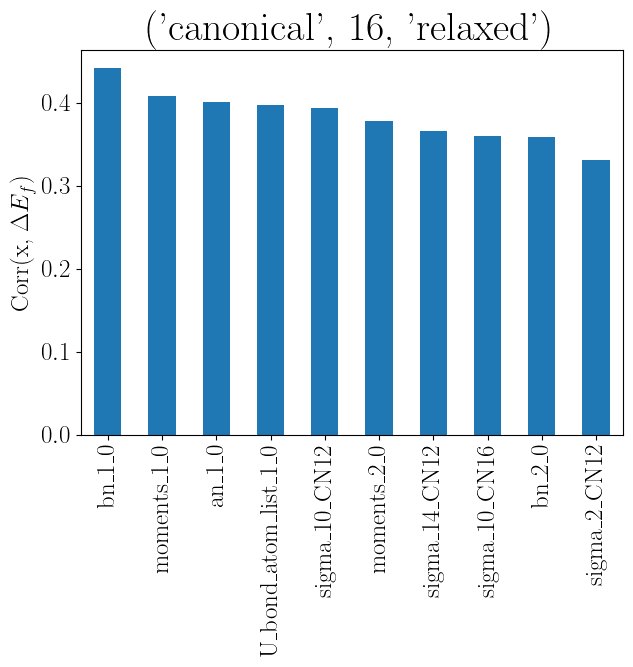

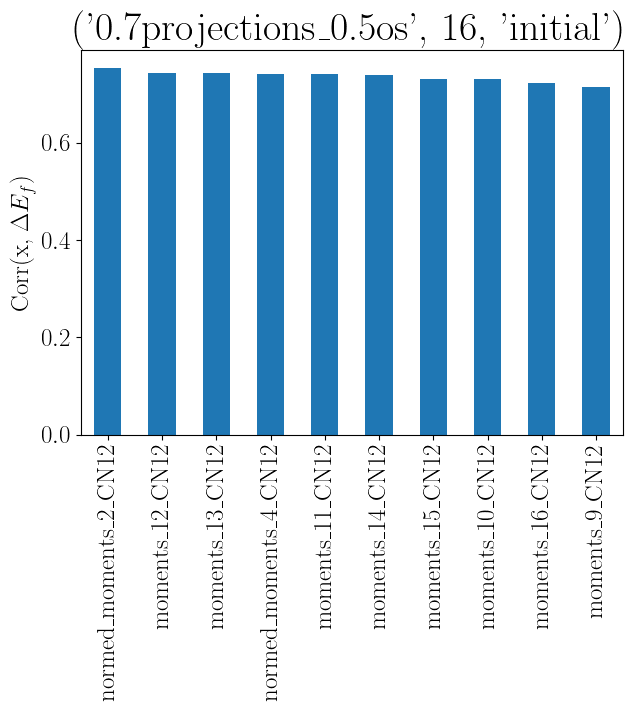

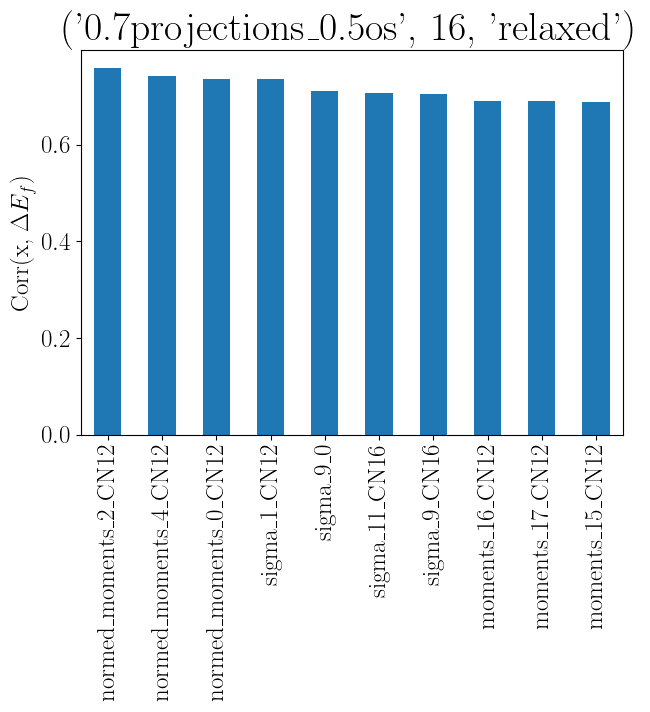

In [173]:
for model, correlations in TargetCorrelations.items():
    fig, ax = plt.subplots()
    ax = correlations[:10].plot(kind='bar', ax = ax)
    ax.set_ylabel(r'Corr(x, $\Delta E_f$)')
    ax.set_title(model)

# save curated CNAV BOPS

In [174]:
BOPG.resultspickle

{('canonical',
  16,
  'initial'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_initial_canonical_table_WUBIND_16.pkl',
 ('canonical',
  16,
  'relaxed'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_relaxed_canonical_table_WUBIND_16.pkl',
 ('0.7projections_0.5os',
  16,
  'initial'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_initial_0.7projections_0.5os_table_WUBIND_16.pkl',
 ('0.7projections_0.5os',
  16,
  'relaxed'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_relaxed_0.7projections_0.5os_table_WUBIND_16.pkl'}

In [175]:
curatedfiles = {key: file.replace('parallel', 'curated') for key,file in BOPG.resultspickle.items()}

In [176]:
[BOPG.resultscnav[key].to_pickle(file) for key, file in curatedfiles.items()]

[None, None, None, None]

# save features correlated to target for ML 

In [177]:
preselection = {}

In [178]:
for model in TargetCorrelations.keys():
    selection = TargetCorrelations[model] > 0.2
    preselection[model] = BOPG.resultscnav[model].loc[:,selection]

In [183]:
BOPG.resultspickle

{('canonical',
  16,
  'initial'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_initial_canonical_table_WUBIND_16.pkl',
 ('canonical',
  16,
  'relaxed'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_relaxed_canonical_table_WUBIND_16.pkl',
 ('0.7projections_0.5os',
  16,
  'initial'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_initial_0.7projections_0.5os_table_WUBIND_16.pkl',
 ('0.7projections_0.5os',
  16,
  'relaxed'): 'Fe-Mo/Descriptors/parallel_Fe-Mo_relaxed_0.7projections_0.5os_table_WUBIND_16.pkl'}

In [184]:
for model, preselect in preselection.items():
    location = os.path.dirname(BOPG.resultspickle[model])
    preselected_location = os.path.join(location, f'preselected_cnav_{model[0]}_BOPds.pkl')
    preselect.to_pickle(preselected_location)

# save features with low order of moments

In [185]:
smallorder = {}

In [186]:
for model, resultscnav in BOPG.resultscnav.items():
    smallorder[model]=resultscnav.filter(regex='an_[0-6]_|bn_[0-6]|^moments_[0-6]|normed|sigma_[0-6]_')
    location = os.path.dirname(BOPG.resultspickle[model])
    smallorder_location = os.path.join(location, f'smallorder_cnav_{model[0]}_BOP.pkl')
    smallorder[model].to_pickle(smallorder_location)

In [187]:
# doprints = [print(pre) for pre in preselected if 'CN12' in pre]

# Distributions by Magnetism 

In [188]:
mag = 'FM'

In [207]:
watch_model = ( '0.7projections_0.5os', 16, 'relaxed' )

In [208]:
def extract_mag_from_index(features_df : pd.core.frame.DataFrame):
    return features_df.index.str.split('.').map(lambda i: i[-1])

In [209]:
Mag = extract_mag_from_index(BOPG.resultscnav[watch_model]) #.index.str.split('.').map(lambda i: i[-1])

In [220]:
def get_mag_case_feature_split(feature_df : pd.core.frame.DataFrame, mag:str, Mag = Mag):
    cased_feature : pd.core.frame.DataFrame = feature_df.loc[Mag == mag]
    cased_feature.index = cased_feature.index.str.replace('.NM$|.FM$','', regex=True)
    return cased_feature
    

Text(0, 0.5, 'No Mag normed moment 1')

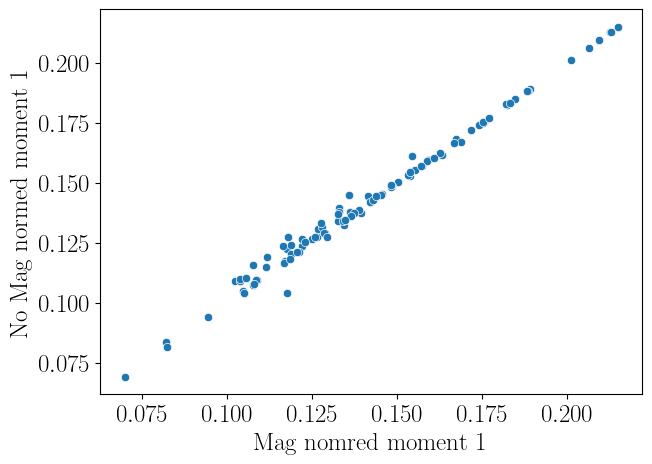

In [222]:
magbop = {watch_model : get_mag_case_feature_split(BOPG.resultscnav[watch_model], 'FM', Mag = Mag)}
nomagbop = {watch_model: get_mag_case_feature_split(BOPG.resultscnav[watch_model], 'NM', Mag = Mag)}
nomag_and_mag = nomagbop[watch_model].index.intersection(magbop[watch_model].index)
x = np.linspace(magbop[watch_model].normed_moments_1_0.min(),magbop[watch_model].normed_moments_1_0.max(), 2)
ax = sns.scatterplot(x = magbop[watch_model].normed_moments_1_0, y = nomagbop[watch_model].normed_moments_1_0)
#sns.lineplot(x=x,y=x, label = 'x=y', color='k')
ax.set_xlabel('Mag nomred moment 1')
ax.set_ylabel('No Mag normed moment 1')